<a href="https://colab.research.google.com/github/WajdAlsuhaymi/IT326-DataMining-Group2/blob/main/Reports/Phase3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 1 – Data Selection

## Project Goal
The main goal of this project is to explore the relationship between social media engagement and emotional well-being. Through data analysis, the project aims to uncover how factors such as time spent, purpose of use, and users’ demographic characteristics influence psychological outcomes. The project seeks to raise awareness about the psychological effects of social media.

## Dataset Source
Kaggle: [Social Media Usage and Emotional Well-being](https://www.kaggle.com/datasets/emirhanai/social-media-usage-and-emotional-well-being)


# Read the file

In [ ]:
import pandas as pd


url = "https://raw.githubusercontent.com/WajdAlSuhaymi/IT326-DataMining-Group2/main/Dataset/Raw_dataset.csv"

# قراءة الملف
df = pd.read_csv(url)

# عرض أول 5 صفوف للتأكد
df.head()


,User_ID,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
0,1.0,25.0,Female,Instagram,120.0,3.0,45.0,10.0,12.0,Happiness
1,2.0,30.0,Male,Twitter,90.0,5.0,20.0,25.0,30.0,Anger
2,3.0,22.0,Non-binary,Facebook,60.0,2.0,15.0,5.0,20.0,Neutral
3,4.0,28.0,Female,Instagram,200.0,8.0,100.0,30.0,50.0,Anxiety
4,5.0,33.0,Male,LinkedIn,45.0,1.0,5.0,2.0,10.0,Boredom


## Dataset Description and **Exploration**

In [ ]:
import pandas as pd



# --------------------------------------------
# معلومات عامة عن البيانات
print("\n🔹 General Info:")
df.info()

# --------------------------------------------
# عدد السجلات (الصفوف) وعدد الأعمدة
print("\n🔹 Dataset shape (rows, columns):", df.shape)

# --------------------------------------------
# التحقق من القيم المفقودة (اختياري لكنه مفيد)
print("\n🔹 Missing values per column:")
print(df.isnull().sum())

# --------------------------------------------
# تحديد العمود الخاص بالتصنيف (Class Attribute)
# في هذه البيانات العمود هو 'Emotion' أو 'Dominant_Emotion' حسب الاسم في ملفك
class_column = 'Dominant_Emotion' # غيّري الاسم إذا مكتوب 'Dominant_Emotion'

# القيم (الفئات) الموجودة في هذا العمود
print("\n🔹 Unique emotion labels:")
print(df[class_column].unique())

# --------------------------------------------
# عدد السجلات في كل فئة (label)
print("\n🔹 Count of instances per label:")
print(df[class_column].value_counts())

# --------------------------------------------
# أنواع البيانات (Attributes types)
print("\n🔹 Data types of attributes:")
print(df.dtypes)

# --------------------------------------------


🔹 General Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 924 entries, 0 to 923
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   User_ID                     924 non-null    float64
 1   Age                         924 non-null    float64
 2   Gender                      924 non-null    object 
 3   Platform                    924 non-null    object 
 4   Daily_Usage_Time (minutes)  924 non-null    float64
 5   Posts_Per_Day               924 non-null    float64
 6   Likes_Received_Per_Day      924 non-null    float64
 7   Comments_Received_Per_Day   924 non-null    float64
 8   Messages_Sent_Per_Day       924 non-null    float64
 9   Dominant_Emotion            924 non-null    object 
dtypes: float64(7), object(3)
memory usage: 72.3+ KB

🔹 Dataset shape (rows, columns): (924, 10)

🔹 Missing values per column:
User_ID                       0
Age                           0
Gen

# Normalize Gender Attribute

In [ ]:
import re
import numpy as np
import pandas as pd

# --- تنظيف وضبط عمود Gender بحيث يكون فقط: Male / Female / Non-binary ---
def normalize_gender(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip().str.lower()

    # خرائط سريعة للقيم الشائعة
    mapping = {
        "m":"male","male":"male","man":"male","boy":"male","masculine":"male","1":"male",
        "f":"female","female":"female","woman":"female","girl":"female","feminine":"female","0":"female",
        "nb":"non-binary","nonbinary":"non-binary","non-binary":"non-binary","non binary":"non-binary",
        "2":"non-binary","other":"non-binary","others":"non-binary"
    }

    # تحويل مباشر إن وُجدت مطابقة كاملة
    s = s.map(lambda x: mapping.get(x, x))

    # محاولات regex للأخطاء الإملائية المحتملة
    s = s.str.replace(r'[^a-z\- ]', '', regex=True)          # إزالة رموز/أرقام
    s = s.str.replace(r'\s+', ' ', regex=True).str.strip()

    # تصنيف بالكلمات المفتاحية
    s = s.replace({
        r'.*\bmale\b.*': 'male',
        r'.*\bfemale\b.*': 'female',
        r'.*\bnon[- ]?binary\b.*': 'non-binary',
        r'^\b(m|man|boy)\b$': 'male',
        r'^\b(f|woman|girl)\b$': 'female',
        r'^\b(nb)\b$': 'non-binary',
    }, regex=True)

    # أي شيء ليس إحدى القيم الثلاث → NaN (نلغيّه بدل ما يطلع أرقام)
    s = s.where(s.isin(["male","female","non-binary"]), np.nan)

    # أرجعها بحالة عنوانية
    return s.map({"male":"Male","female":"Female","non-binary":"Non-binary"})

# طبّقي على داتا سِتك
df["Gender"] = normalize_gender(df["Gender"])

# --- تلخيص Gender فقط بشكل ثابت بالترتيب المطلوب ---
present = [v for v in ["Male","Female","Non-binary"] if v in df["Gender"].dropna().unique().tolist()]
gender_summary = " - ".join(present) if present else "—"
print("Gender → Nominal:", gender_summary)


Gender → Nominal: Male - Female - Non-binary


# Summarize Attributes and there types
 User_ID: Unique identifier for the user.

 Age: Age of the user.

 Gender: Gender of the user (Female, Male, Non-binary).

 Platform: Social media platform used (e.g., Instagram, Twitter, Facebook, LinkedIn, Snapchat, Whatsapp, Telegram).

 Daily_Usage_Time (minutes): Daily time spent on the platform in minutes.

 Posts_Per_Day: Number of posts made per day.

 Likes_Received_Per_Day: Number of likes received per day.

 Comments_Received_Per_Day: Number of comments received per day.

 Messages_Sent_Per_Day: Number of messages sent per day.

 Dominant_Emotion: User's dominant emotional state during the day (e.
 g., Happiness, Sadness, Anger, Anxiety, Boredom, Neutral).

In [ ]:
import pandas as pd, numpy as np, re

# =============== 0) قراءة الداتا ===============
try:
    df  # إن كانت df موجودة مسبقًا
except NameError:
    df = pd.read_csv("Raw_dataset.csv")

# =============== 1) تنظيف Gender ثم تثبيته ===============
def normalize_gender(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip().str.lower()

    mapping = {
        "m":"male","male":"male","man":"male","boy":"male","masculine":"male","1":"male",
        "f":"female","female":"female","woman":"female","girl":"female","feminine":"female","0":"female",
        "nb":"non-binary","nonbinary":"non-binary","non-binary":"non-binary","non binary":"non-binary",
        "2":"non-binary","other":"non-binary","others":"non-binary"
    }
    s = s.map(lambda x: mapping.get(x, x))
    s = s.str.replace(r'[^a-z\- ]', '', regex=True).str.replace(r'\s+', ' ', regex=True).str.strip()
    s = s.replace({
        r'.*\bmale\b.*': 'male',
        r'.*\bfemale\b.*': 'female',
        r'.*\bnon[- ]?binary\b.*': 'non-binary',
        r'^\b(m|man|boy)\b$': 'male',
        r'^\b(f|woman|girl)\b$': 'female',
        r'^\b(nb)\b$': 'non-binary',
    }, regex=True)
    s = s.where(s.isin(["male","female","non-binary"]), np.nan)
    return s.map({"male":"Male","female":"Female","non-binary":"Non-binary"})

if "Gender" in df.columns:
    df["Gender"] = normalize_gender(df["Gender"])

# =============== 2) أدوات مساعدة للتلخيص ===============
def to_numeric_or_range(series: pd.Series):
    s = series.astype(str).str.strip()
    out = pd.Series(np.nan, index=s.index)
    for i, val in s.items():
        if re.fullmatch(r"\d+(\.\d+)?", val):
            out.at[i] = float(val)
        elif re.fullmatch(r"\d+\s*-\s*\d+", val):
            a, b = map(float, re.findall(r"\d+", val))
            out.at[i] = (a + b) / 2
    return out

def summarize_one(col: str, max_list=15):
    s = df[col].dropna()

    # --- الشرط الخاص بـ Gender: دائماً Nominal بالقيم الثلاث ---
    if col == "Gender":
        return "Nominal", "Male - Female - Non-binary"

    # محاولة اعتباره رقميًا مباشرة
    num = pd.to_numeric(s, errors="coerce")
    if num.notna().any():
        mn, mx = num.min(), num.max()
        fmt = lambda v: f"{int(v)}" if float(v).is_integer() else f"{v:.4g}"
        return "Numeric", f"{fmt(mn)} - {fmt(mx)}"

    # محاولة تحويل نطاقات نصية لأرقام
    num2 = to_numeric_or_range(s)
    if num2.notna().any():
        mn, mx = num2.min(), num2.max()
        fmt = lambda v: f"{int(v)}" if float(v).is_integer() else f"{v:.4g}"
        return "Numeric", f"{fmt(mn)} - {fmt(mx)}"

    # اسمي (Nominal)
    uniq = sorted(s.astype(str).str.strip().unique(), key=lambda x: x.lower())
    vals = " - ".join(uniq[:max_list]) + (f" - ... (+{len(uniq)-max_list} more)" if len(uniq) > max_list else "")
    return "Nominal", (vals if vals else "—")

# =============== 3) بناء جدول الملخص ===============
order = [
    "User_ID","Age","Gender","Platform",
    "Daily_Usage_Time (minutes)","Posts_Per_Day","Likes_Received_Per_Day",
    "Comments_Received_Per_Day","Messages_Sent_Per_Day","Dominant_Emotion"
]

rows = []
for col in order:
    if col not in df.columns:
        rows.append({"Attribute": f"{col} (NOT FOUND)", "Type": "-", "Range / Possible Values": "-"})
        continue
    t, rng = summarize_one(col, max_list=15)
    rows.append({"Attribute": col, "Type": t, "Range / Possible Values": rng})

summary = pd.DataFrame(rows)
summary["__o__"] = summary["Type"].map({"Numeric": 0, "Nominal": 1}).fillna(2)
summary = summary.sort_values(["__o__", "Attribute"]).drop(columns="__o__").reset_index(drop=True)

# عرض النتيجة
summary

,Attribute,Type,Range / Possible Values
0,Age,Numeric,21 - 35
1,Comments_Received_Per_Day,Numeric,2 - 40
2,Daily_Usage_Time (minutes),Numeric,40 - 200
3,Likes_Received_Per_Day,Numeric,5 - 110
4,Messages_Sent_Per_Day,Numeric,8 - 50
5,Posts_Per_Day,Numeric,1 - 8
6,User_ID,Numeric,1 - 1000
7,Dominant_Emotion,Nominal,Anger - Anxiety - Boredom - Happiness - Neutra...
8,Gender,Nominal,Male - Female - Non-binary
9,Platform,Nominal,Facebook - Instagram - LinkedIn - Snapchat - T...


# Phase 2 – Data Summarization and Preprocessing

This phase focuses on analyzing and preparing the dataset before applying data mining techniques.
It includes summarizing data, visualizing relationships, handling missing values, and applying preprocessing techniques such as encoding, normalization, and outlier removal.

### **Part** 1 : Data Summarization

In [ ]:

# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Loading the Dataset
url='https://raw.githubusercontent.com/WajdAlSuhaymi/IT326-DataMining-Group2/main/Dataset/Raw_dataset.csv'
df = pd.read_csv(url)
df.head()


,User_ID,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
0,1.0,25.0,Female,Instagram,120.0,3.0,45.0,10.0,12.0,Happiness
1,2.0,30.0,Male,Twitter,90.0,5.0,20.0,25.0,30.0,Anger
2,3.0,22.0,Non-binary,Facebook,60.0,2.0,15.0,5.0,20.0,Neutral
3,4.0,28.0,Female,Instagram,200.0,8.0,100.0,30.0,50.0,Anxiety
4,5.0,33.0,Male,LinkedIn,45.0,1.0,5.0,2.0,10.0,Boredom


In [ ]:
# General Information and Missing Values
print("Dataset Shape:", df.shape)
df.info()

# Missing values summary
missing_values = df.isnull().sum()
missing_values[missing_values > 0].sort_values(ascending=False)


Dataset Shape: (924, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 924 entries, 0 to 923
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   User_ID                     924 non-null    float64
 1   Age                         924 non-null    float64
 2   Gender                      924 non-null    object 
 3   Platform                    924 non-null    object 
 4   Daily_Usage_Time (minutes)  924 non-null    float64
 5   Posts_Per_Day               924 non-null    float64
 6   Likes_Received_Per_Day      924 non-null    float64
 7   Comments_Received_Per_Day   924 non-null    float64
 8   Messages_Sent_Per_Day       924 non-null    float64
 9   Dominant_Emotion            924 non-null    object 
dtypes: float64(7), object(3)
memory usage: 72.3+ KB


,0


In [ ]:
# Statistical Summary
df.describe().T  # Includes five-number summary for numeric columns


,count,mean,std,min,25%,50%,75%,max
User_ID,924.0,498.937229,291.713692,1.0,231.75,500.5,731.25,1000.0
Age,924.0,27.500000,3.941473,21.0,24.00,27.0,30.00,35.0
Daily_Usage_Time (minutes),924.0,96.309524,39.228274,40.0,65.00,85.0,120.00,200.0
Posts_Per_Day,924.0,3.349567,1.940080,1.0,2.00,3.0,5.00,8.0
Likes_Received_Per_Day,924.0,40.246753,26.799196,5.0,19.50,33.0,55.00,110.0
Comments_Received_Per_Day,924.0,15.726190,8.933589,2.0,8.00,14.0,22.00,40.0
Messages_Sent_Per_Day,924.0,22.595238,8.634295,8.0,17.00,22.0,28.00,50.0


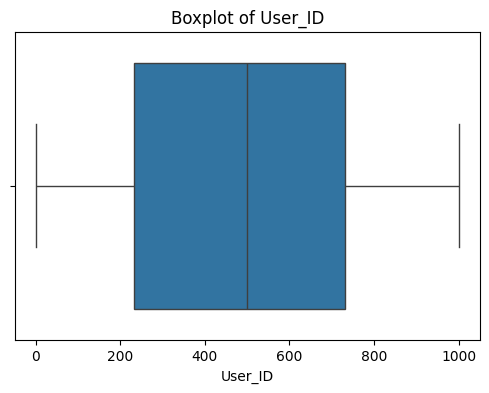

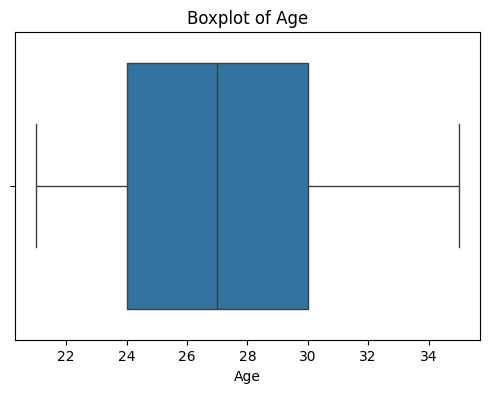

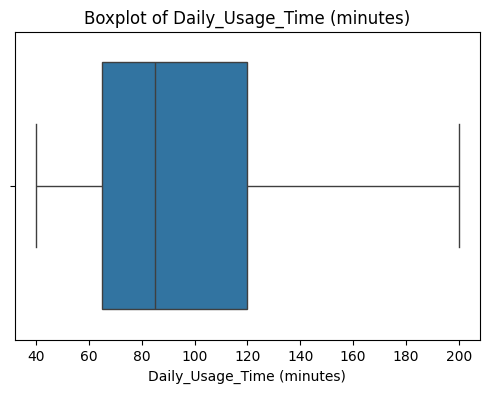

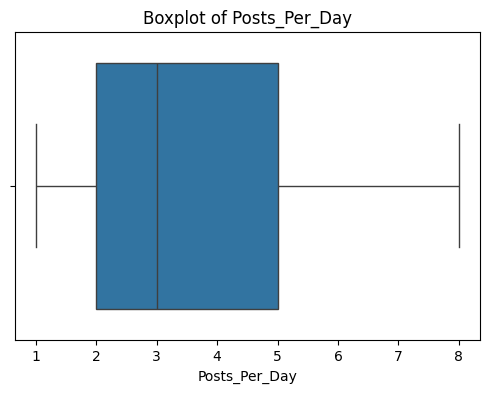

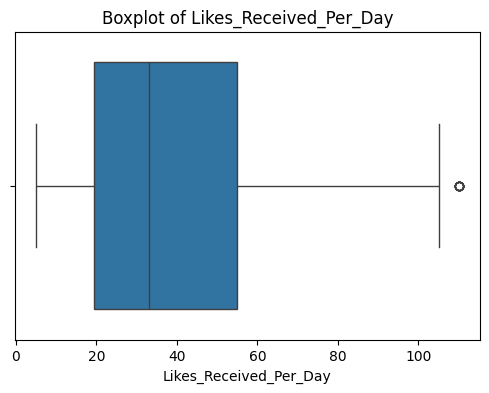

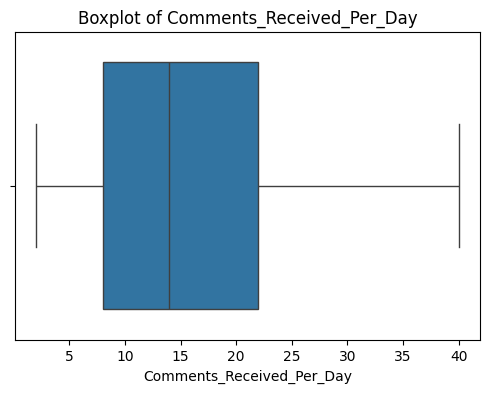

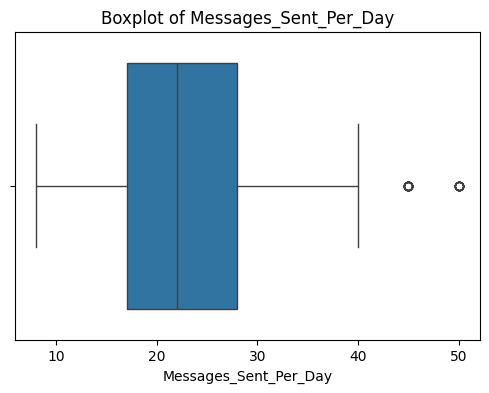

In [ ]:
# Boxplots and Outlier Detection
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x=col)
    plt.title(f'Boxplot of {col}')
    plt.show()


The boxplots were created to quickly visualize the distribution of each numeric variable and detect potential outliers. They illustrate the median, spread, and skewness of each feature, along with any extreme values that fall outside the normal range. From these graphs, you can conclude which variables contain outliers, which ones are skewed, and whether certain features may require cleaning, scaling, or transformation before further analysis or modeling.

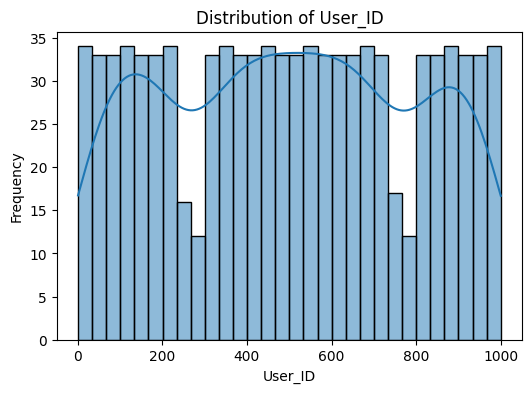

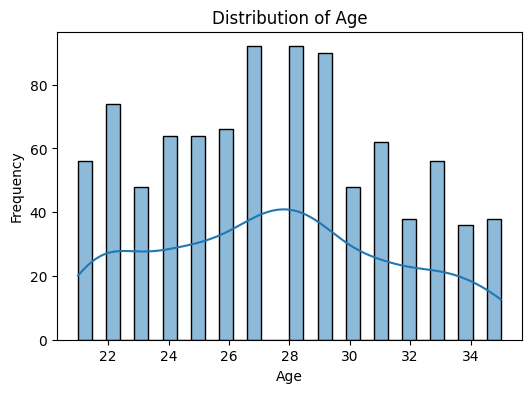

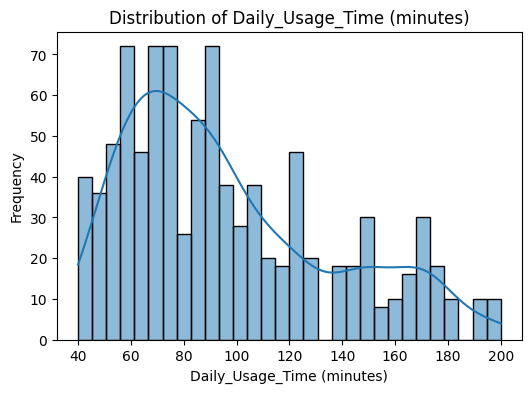

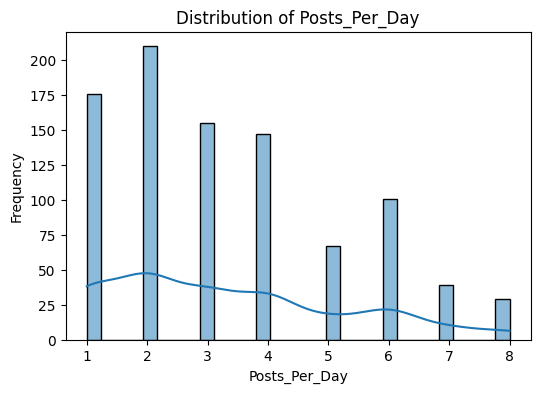

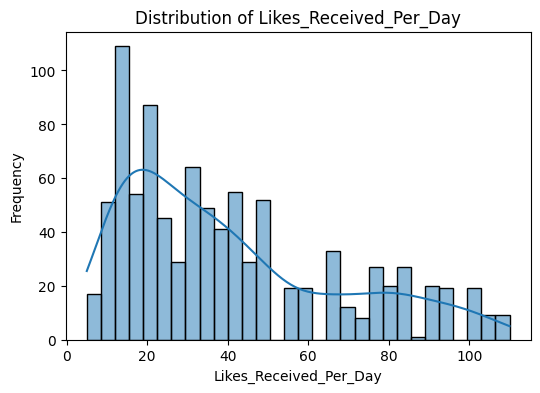

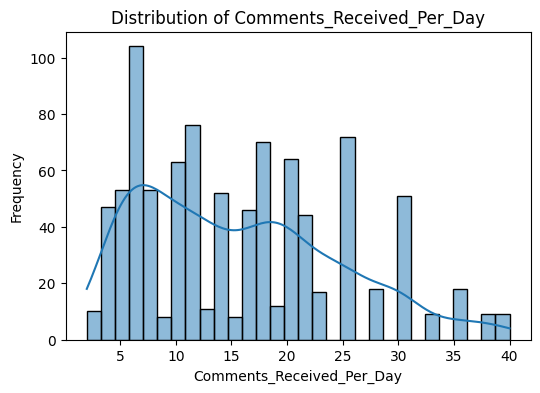

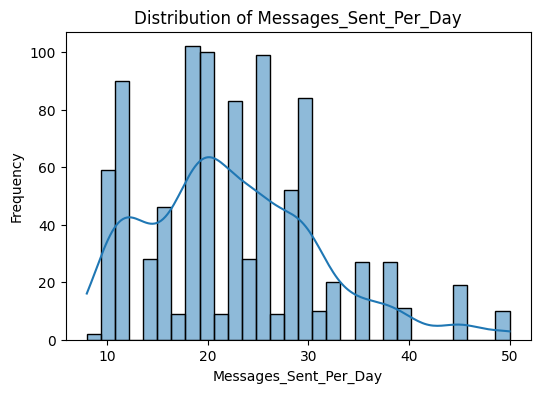

In [ ]:
# Histograms for Numeric Distributions
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()


The histograms were created to examine the underlying distribution of each numeric variable, helping determine whether the data is normal, skewed, uniform, or multimodal. Each graph illustrates the frequency of values within bins, along with a KDE curve that highlights the overall shape and smoothness of the distribution. From these histograms, you can conclude how spread out each variable is, whether the data is concentrated in specific ranges, if transformations might be needed (e.g., for skewed data), and whether any unusual patterns or multiple peaks suggest different subgroups or behaviors in the dataset.

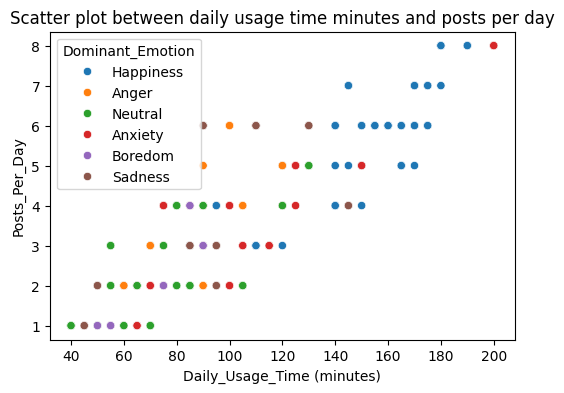

In [ ]:
# Scatter Plot (Pairwise Comparison)
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='Daily_Usage_Time (minutes)', y='Posts_Per_Day', hue='Dominant_Emotion')
plt.title('Scatter plot between daily usage time minutes and posts per day')
plt.show()


The scatter plot was created to explore the relationship between daily usage time and the number of posts per day, with color-coding added to observe how dominant emotions vary across this relationship. It illustrates how the two variables interact—whether they show a positive or negative trend, clusters, or randomness—while also showing whether certain emotional states are associated with higher or lower usage or posting patterns. From this graph, you can conclude whether increased usage time corresponds to more frequent posting, identify any visible patterns or groupings among users with different dominant emotions, and detect possible behavioral trends or outliers that may warrant deeper analysis.

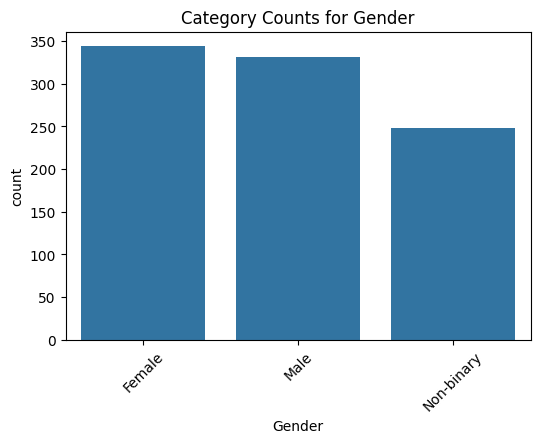

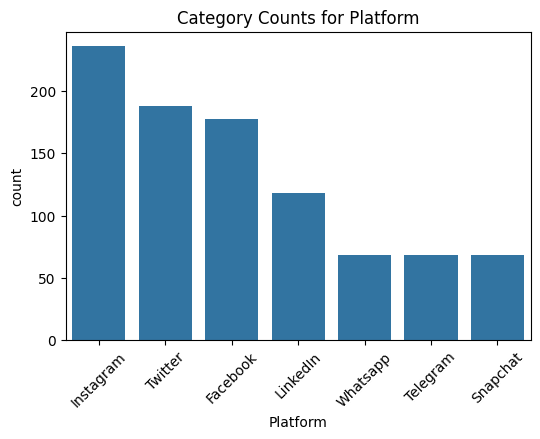

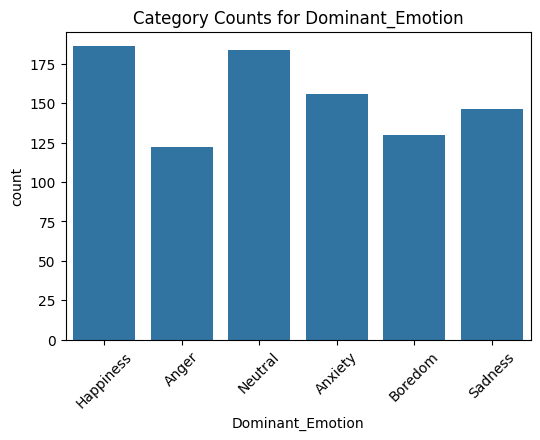

In [ ]:
# Bar Plots for Categorical Features
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col)
    plt.title(f'Category Counts for {col}')
    plt.xticks(rotation=45)
    plt.show()


The bar plots were created to visualize the frequency distribution of each categorical feature, allowing you to quickly see how often each category appears in the dataset. They illustrate the counts of all unique categories within a variable, making it easy to spot dominant groups, rare categories, and overall balance or imbalance in the data. From these graphs, you can conclude which categories are most common, whether the feature is skewed toward certain groups, and whether rare categories may need merging, encoding adjustments, or special handling during analysis or modeling.

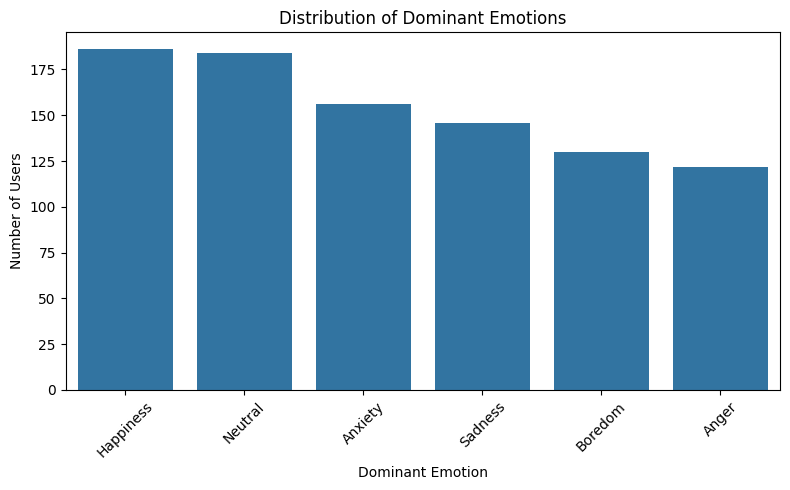

In [ ]:
# Class Label Distribution

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Dominant_Emotion', order=df['Dominant_Emotion'].value_counts().index)
plt.title('Distribution of Dominant Emotions')
plt.xlabel('Dominant Emotion')
plt.ylabel('Number of Users')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


This bar plot was created to examine the distribution of the target variable, Dominant Emotion, ensuring a clear understanding of how balanced or imbalanced the emotion classes are. It illustrates the frequency of each emotion category in descending order, making it easy to see which emotions are most common and which are underrepresented. From this graph, you can conclude whether the dataset suffers from class imbalance—important for model training—and identify which emotions dominate the user base, which may also reveal general emotional trends within the population.

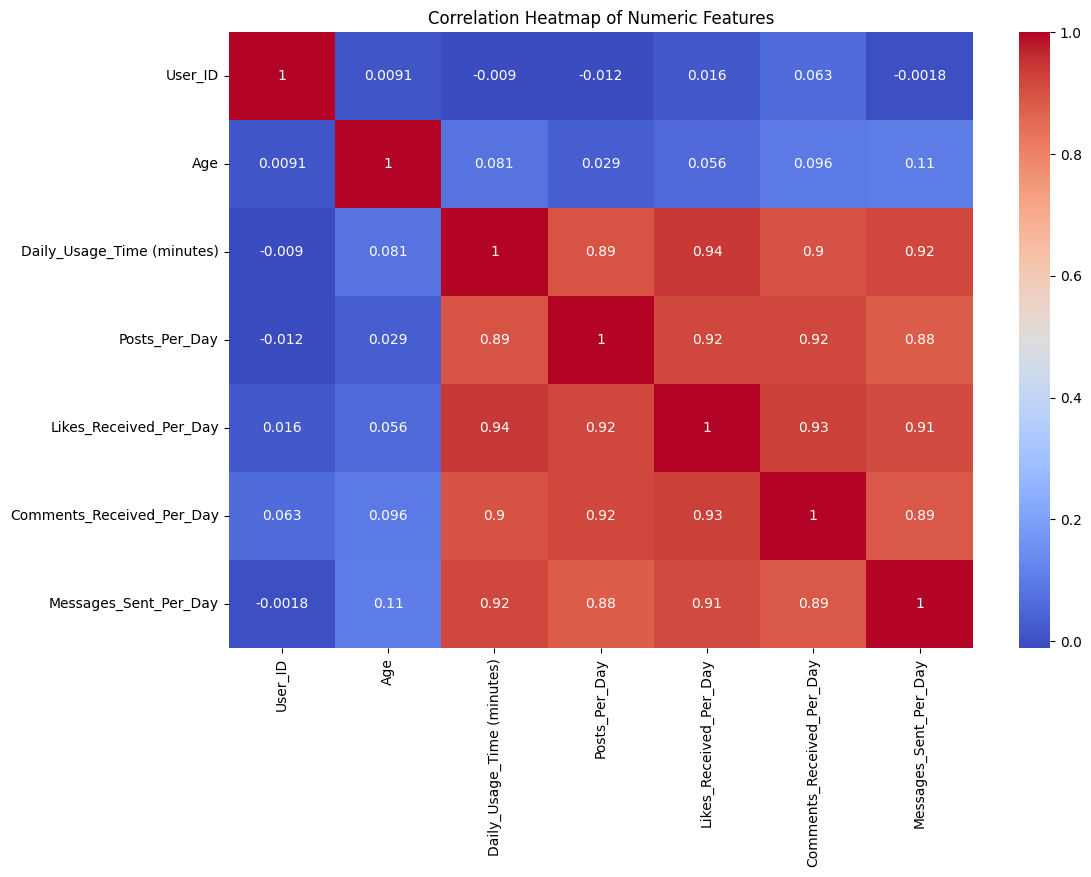

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()


The correlation heatmap was created to understand how the numeric variables in the dataset relate to each other and to identify any strong positive or negative correlations. It illustrates the pairwise correlation coefficients between all numeric features, using color intensity and annotated values to highlight the strength and direction of each relationship. From this graph, you can conclude which variables move together, which ones are inversely related, and whether any features are highly correlated enough to indicate redundancy or multicollinearity—important for feature selection, interpretation, and improving model performance.

### **Part 2**: Data Preprocessing

In [ ]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

## Handling Missing Values

We used mean to fill missing numeric values and mode for categorical columns (Gender, Platform, Dominant_Emotion).
This was done to avoid losing rows and keep the dataset complete for analysis









In [ ]:
import pandas as pd

# Load the cleaned dataset
df = pd.read_csv("https://raw.githubusercontent.com/WajdAlSuhaymi/IT326-DataMining-Group2/main/Dataset/Raw_dataset.csv")

# Drop any completely empty rows
df = df.dropna(how='all')

print("Shape after dropping empty rows:", df.shape)

# Create a new DataFrame for preprocessing
df_processed = df.copy()

print("A new copy 'df_processed' is created for preprocessing.")
df_processed.head()


Shape after dropping empty rows: (924, 10)
A new copy 'df_processed' is created for preprocessing.


,User_ID,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
0,1.0,25.0,Female,Instagram,120.0,3.0,45.0,10.0,12.0,Happiness
1,2.0,30.0,Male,Twitter,90.0,5.0,20.0,25.0,30.0,Anger
2,3.0,22.0,Non-binary,Facebook,60.0,2.0,15.0,5.0,20.0,Neutral
3,4.0,28.0,Female,Instagram,200.0,8.0,100.0,30.0,50.0,Anxiety
4,5.0,33.0,Male,LinkedIn,45.0,1.0,5.0,2.0,10.0,Boredom


In [ ]:
import pandas as pd

# Load cleaned dataset
df = pd.read_csv("https://raw.githubusercontent.com/WajdAlSuhaymi/IT326-DataMining-Group2/main/Dataset/Raw_dataset.csv")

# Drop any completely empty rows
df = df.dropna(how='all')

# Create a new dataset for preprocessing
df_processed = df.copy()

# Define numeric columns
numeric_cols = [
    "Age",
    "Daily_Usage_Time (minutes)",
    "Posts_Per_Day",
    "Likes_Received_Per_Day",
    "Comments_Received_Per_Day",
    "Messages_Sent_Per_Day"
]

# Convert numeric columns to proper numeric dtype
df_processed[numeric_cols] = df_processed[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Fill missing numeric values with mean for each column
for col in numeric_cols:
    df_processed[col] = df_processed[col].fillna(df_processed[col].mean())

print("✔ Numeric columns cleaned and missing values filled successfully!")
df_processed.head()


✔ Numeric columns cleaned and missing values filled successfully!


,User_ID,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
0,1.0,25.0,Female,Instagram,120.0,3.0,45.0,10.0,12.0,Happiness
1,2.0,30.0,Male,Twitter,90.0,5.0,20.0,25.0,30.0,Anger
2,3.0,22.0,Non-binary,Facebook,60.0,2.0,15.0,5.0,20.0,Neutral
3,4.0,28.0,Female,Instagram,200.0,8.0,100.0,30.0,50.0,Anxiety
4,5.0,33.0,Male,LinkedIn,45.0,1.0,5.0,2.0,10.0,Boredom


## 1) Loading the Raw Dataset
We loaded the raw dataset and removed any completely empty rows to ensure data consistency before preprocessing.

In [ ]:
import pandas as pd

# تحميل الداتا من الراو مرّة واحدة
df = pd.read_csv("https://raw.githubusercontent.com/WajdAlSuhaymi/IT326-DataMining-Group2/main/Dataset/Raw_dataset.csv")

# حذف الصفوف الفارغة بالكامل (احتياطي)
df = df.dropna(how='all')

# إنشاء نسخة للبروسسينق
df_processed = df.copy()

print("Shape:", df_processed.shape)
df_processed.head()


Shape: (924, 10)


,User_ID,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
0,1.0,25.0,Female,Instagram,120.0,3.0,45.0,10.0,12.0,Happiness
1,2.0,30.0,Male,Twitter,90.0,5.0,20.0,25.0,30.0,Anger
2,3.0,22.0,Non-binary,Facebook,60.0,2.0,15.0,5.0,20.0,Neutral
3,4.0,28.0,Female,Instagram,200.0,8.0,100.0,30.0,50.0,Anxiety
4,5.0,33.0,Male,LinkedIn,45.0,1.0,5.0,2.0,10.0,Boredom


## 2) Cleaning Numeric Attributes
We converted all numeric attributes to proper numerical format and filled missing values using the mean of each column.
This ensures that the dataset contains no null values and remains suitable for machine learning algorithms.

In [ ]:
# تعريف الأعمدة الرقمية
numeric_cols = [
    "Age",
    "Daily_Usage_Time (minutes)",
    "Posts_Per_Day",
    "Likes_Received_Per_Day",
    "Comments_Received_Per_Day",
    "Messages_Sent_Per_Day"
]

# تحويل للأرقام (احتياط)
df_processed[numeric_cols] = df_processed[numeric_cols].apply(pd.to_numeric, errors='coerce')

# تعويض القيم الناقصة بالمتوسط لكل عمود
for col in numeric_cols:
    df_processed[col] = df_processed[col].fillna(df_processed[col].mean())

print("✔ Numeric columns cleaned and missing values filled.")
df_processed[numeric_cols].head()


✔ Numeric columns cleaned and missing values filled.


,Age,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day
0,25.0,120.0,3.0,45.0,10.0,12.0
1,30.0,90.0,5.0,20.0,25.0,30.0
2,22.0,60.0,2.0,15.0,5.0,20.0
3,28.0,200.0,8.0,100.0,30.0,50.0
4,33.0,45.0,1.0,5.0,2.0,10.0


## 3) Discretization (Age Binning) – For Analysis Only
We applied binning on the Age attribute by grouping users into defined age ranges.
This step helps analyze behavioral differences between age groups.
(This transformation was used only for reporting and was not stored as a new column.)

In [ ]:
# Binning على العمر الحقيقي للتحليل فقط (لا نحفظه ككولوم)
bins = [20, 25, 30, 35]
labels = ['21–25', '26–30', '31–35']

age_binned_temp = pd.cut(df_processed['Age'], bins=bins, labels=labels, include_lowest=True)

print("✔ Binning based on REAL Age (for analysis only):")
print(age_binned_temp.value_counts())


✔ Binning based on REAL Age (for analysis only):
Age
26–30    388
21–25    306
31–35    230
Name: count, dtype: int64


## 4) Encoding Categorical Data
We applied Label Encoding on the categorical attributes Gender and Platform.
This converts textual categories into numerical values that machine learning algorithms can process.
The target class (Dominant_Emotion) was excluded from encoding.

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_cols = ["Gender", "Platform"]

for col in label_cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))

print("✔ Label encoding applied on Gender and Platform.")
df_processed[label_cols].head()


✔ Label encoding applied on Gender and Platform.


,Gender,Platform
0,0,1
1,1,5
2,2,0
3,0,1
4,1,2


## 5) Normalization
We applied Min–Max Normalization to scale all numeric attributes between 0 and 1.
This ensures that features with larger numeric ranges (such as usage time) do not dominate the learning process.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

numeric_to_scale = [
    "Age",
    "Daily_Usage_Time (minutes)",
    "Posts_Per_Day",
    "Likes_Received_Per_Day",
    "Comments_Received_Per_Day",
    "Messages_Sent_Per_Day",
    "Gender"  # الآن صار رقمي ونقدر نطبّعه
]

scaler = MinMaxScaler()
df_processed[numeric_to_scale] = scaler.fit_transform(df_processed[numeric_to_scale])

print("✔ Normalization applied on numeric columns (including Age & Gender).")
df_processed[numeric_to_scale].head()


✔ Normalization applied on numeric columns (including Age & Gender).


,Age,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Gender
0,0.285714,0.50000,0.285714,0.380952,0.210526,0.095238,0.0
1,0.642857,0.31250,0.571429,0.142857,0.605263,0.523810,0.5
2,0.071429,0.12500,0.142857,0.095238,0.078947,0.285714,1.0
3,0.500000,1.00000,1.000000,0.904762,0.736842,1.000000,0.0
4,0.857143,0.03125,0.000000,0.000000,0.000000,0.047619,0.5


### 6) Age Normalization
After examining the age distribution, we normalized the Age column using Min–Max scaling to keep it consistent with the rest of the normalized numerical features.

## 7) Removing User_ID & Saving
We removed the User_ID attribute because it serves only as an identifier and has no analytical value.
Keeping it would introduce unnecessary noise and could negatively affect model performance.

In [ ]:
# حذف User_ID إذا موجود
if "User_ID" in df_processed.columns:
    df_processed = df_processed.drop(columns=["User_ID"])
    print("✔ 'User_ID' column removed from df_processed.")
else:
    print("ℹ 'User_ID' not found in df_processed.")

print("New DataFrame shape:", df_processed.shape)

# حفظ الملف النهائي في ملف واحد فقط
df_processed.to_csv("Preprocessed_dataset.csv", index=False)
print("✔ Preprocessed_dataset.csv saved successfully!")


✔ 'User_ID' column removed from df_processed.
New DataFrame shape: (924, 9)
✔ Preprocessed_dataset.csv saved successfully!


# Final Data Preprocessing Summary (Phase 2)Technique: Data Export


1. Removed Empty Rows

All completely empty rows were deleted to ensure the dataset contained only valid and usable records.

2. Cleaned and Standardized Numeric Attributes

Numeric columns (Age, Daily Usage Time, Posts Per Day, Likes, Comments, Messages) were converted to proper numeric type using to_numeric() with error handling.
Missing values were filled using mean imputation to maintain data consistency.

3. Age Analysis Using Discretization (Binning – Analysis Only)

Age was grouped into defined categories (21–25, 26–30, 31–35) to study behavioral differences among user groups.
This transformation was temporary and used only for analysis; it was not stored in the final dataset.

4. Encoded Categorical Attributes

Label Encoding was applied to the categorical features Gender and Platform to convert them into numeric form suitable for machine learning algorithms.
The target attribute (Dominant_Emotion) remained unchanged.

5. Normalized Numeric Features

Min–Max Normalization was applied to all continuous numeric attributes—including Age and Gender—to scale them between 0 and 1 and ensure equal weighting in modeling.

6. Removed Irrelevant Attribute

The User_ID column was removed because it only serves as an identifier and has no analytical or predictive value.

7. Saved the Final Preprocessed File

 After completing all preprocessing steps, the cleaned dataset was saved as Preprocessed_dataset.csv, making it ready for use in Phase 3 (data analysis & modeling).

# Summarize Attributes and there types after pre-processing

In [ ]:
# 📊 Enhanced Column Summary Report (for df_processed)
import pandas as pd
import numpy as np

print("🔍 Dataset Columns Summary (df_processed)\n")

for col in df_processed.columns:
    dtype = df_processed[col].dtype

    print(f"📌 Column Name: {col}")
    print(f"   ▪️ Data Type: {dtype}")

    # عدد القيم الفارغة
    missing = df_processed[col].isna().sum()
    print(f"   ▪️ Missing Values: {missing}")

    # إذا العمود رقمي
    if pd.api.types.is_numeric_dtype(df_processed[col]):
        col_min = df_processed[col].min()
        col_max = df_processed[col].max()
        print(f"   ▪️ Range: {col_min} → {col_max}")
    else:
        unique_vals = df_processed[col].unique()
        unique_count = len(unique_vals)
        if unique_count <= 10:
            print(f"   ▪️ Unique Values: {list(unique_vals)}")
        else:
            print(f"   ▪️ Unique Values Count: {unique_count}")

    print("-" * 60)


🔍 Dataset Columns Summary (df_processed)

📌 Column Name: Age
   ▪️ Data Type: float64
   ▪️ Missing Values: 0
   ▪️ Range: 0.0 → 1.0
------------------------------------------------------------
📌 Column Name: Gender
   ▪️ Data Type: float64
   ▪️ Missing Values: 0
   ▪️ Range: 0.0 → 1.0
------------------------------------------------------------
📌 Column Name: Platform
   ▪️ Data Type: int64
   ▪️ Missing Values: 0
   ▪️ Range: 0 → 6
------------------------------------------------------------
📌 Column Name: Daily_Usage_Time (minutes)
   ▪️ Data Type: float64
   ▪️ Missing Values: 0
   ▪️ Range: 0.0 → 1.0
------------------------------------------------------------
📌 Column Name: Posts_Per_Day
   ▪️ Data Type: float64
   ▪️ Missing Values: 0
   ▪️ Range: 0.0 → 1.0
------------------------------------------------------------
📌 Column Name: Likes_Received_Per_Day
   ▪️ Data Type: float64
   ▪️ Missing Values: 0
   ▪️ Range: 0.0 → 1.0
-----------------------------------------------------

# **Phase 3**

#Classification

1. Load The Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('Preprocessed_dataset.csv')
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (924, 9)


,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
0,0.285714,Female,Instagram,120.0,3.0,45.0,10.0,12.0,Happiness
1,0.642857,Male,Twitter,90.0,5.0,20.0,25.0,30.0,Anger
2,0.071429,Non-binary,Facebook,60.0,2.0,15.0,5.0,20.0,Neutral
3,0.500000,Female,Instagram,200.0,8.0,100.0,30.0,50.0,Anxiety
4,0.857143,Male,LinkedIn,45.0,1.0,5.0,2.0,10.0,Boredom


2. Prepocessing

In [ ]:
# Target column = last column
target_col = df.columns[-1]
# Drop missing target rows
df = df.dropna(subset=[target_col]).reset_index(drop=True)
X = df.drop(columns=[target_col])
y = df[target_col]
# Encode target labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)
# One-hot encode categorical features
X = pd.get_dummies(X)
print("Features:", X.shape)
print("Target:", y_encoded.shape)


Features: (924, 16)
Target: (924,)


3. Setting

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
splits = {
"60_40": 0.40,
"70_30": 0.30,
"80_20": 0.20
}
criteria = ["gini", "entropy"]

4. Experiment Loop


Split: 60_40 | Criterion: gini

Accuracy: 0.9649

Classification Report:
              precision    recall  f1-score   support

       Anger       0.96      0.98      0.97        49
     Anxiety       0.97      0.94      0.95        62
     Boredom       0.96      0.96      0.96        52
   Happiness       0.99      0.97      0.98        75
     Neutral       0.99      0.99      0.99        74
     Sadness       0.92      0.95      0.93        58

    accuracy                           0.96       370
   macro avg       0.96      0.96      0.96       370
weighted avg       0.97      0.96      0.96       370



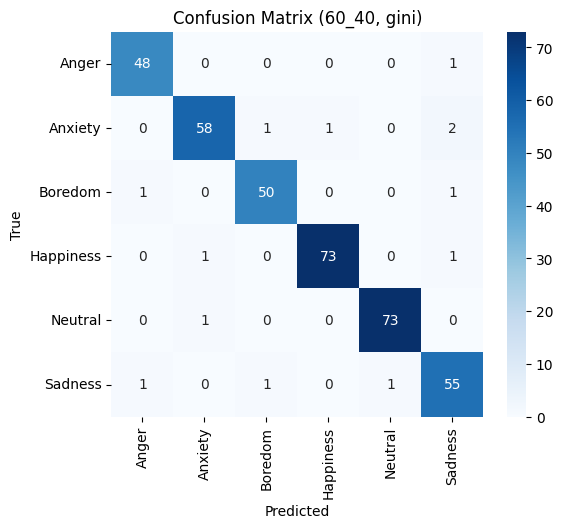

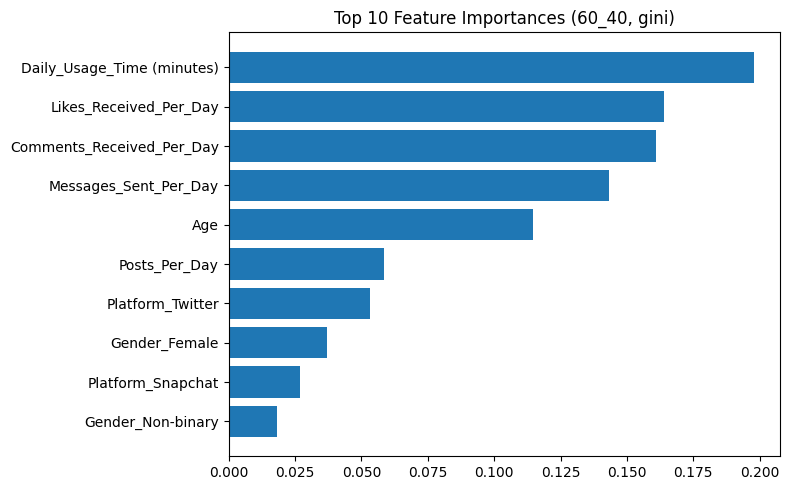

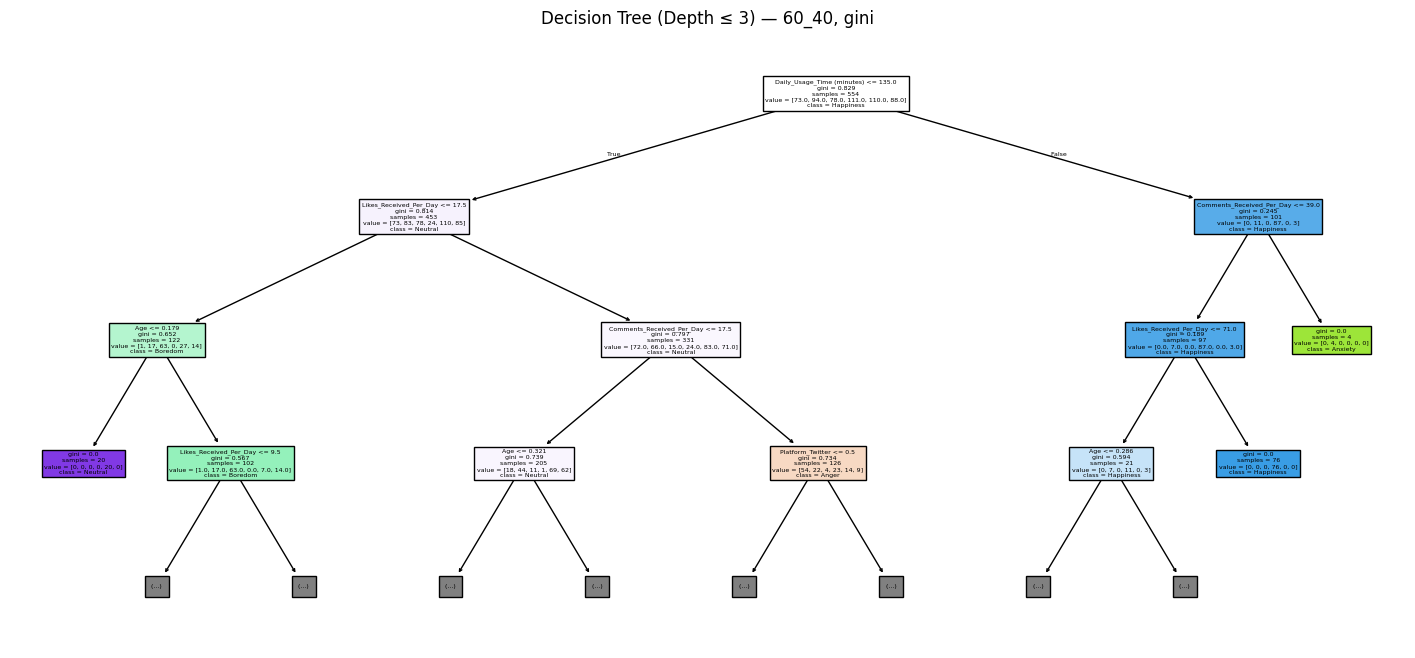


Split: 60_40 | Criterion: entropy

Accuracy: 0.9568

Classification Report:
              precision    recall  f1-score   support

       Anger       0.91      0.98      0.94        49
     Anxiety       0.97      0.95      0.96        62
     Boredom       0.91      0.96      0.93        52
   Happiness       0.99      0.97      0.98        75
     Neutral       0.99      0.95      0.97        74
     Sadness       0.96      0.93      0.95        58

    accuracy                           0.96       370
   macro avg       0.95      0.96      0.95       370
weighted avg       0.96      0.96      0.96       370



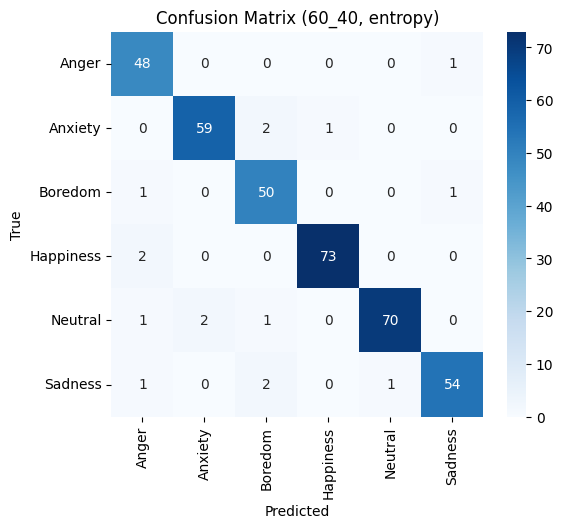

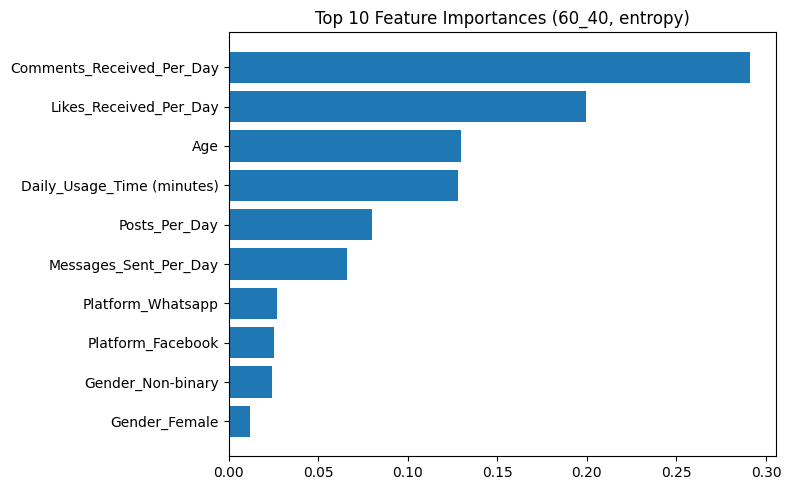

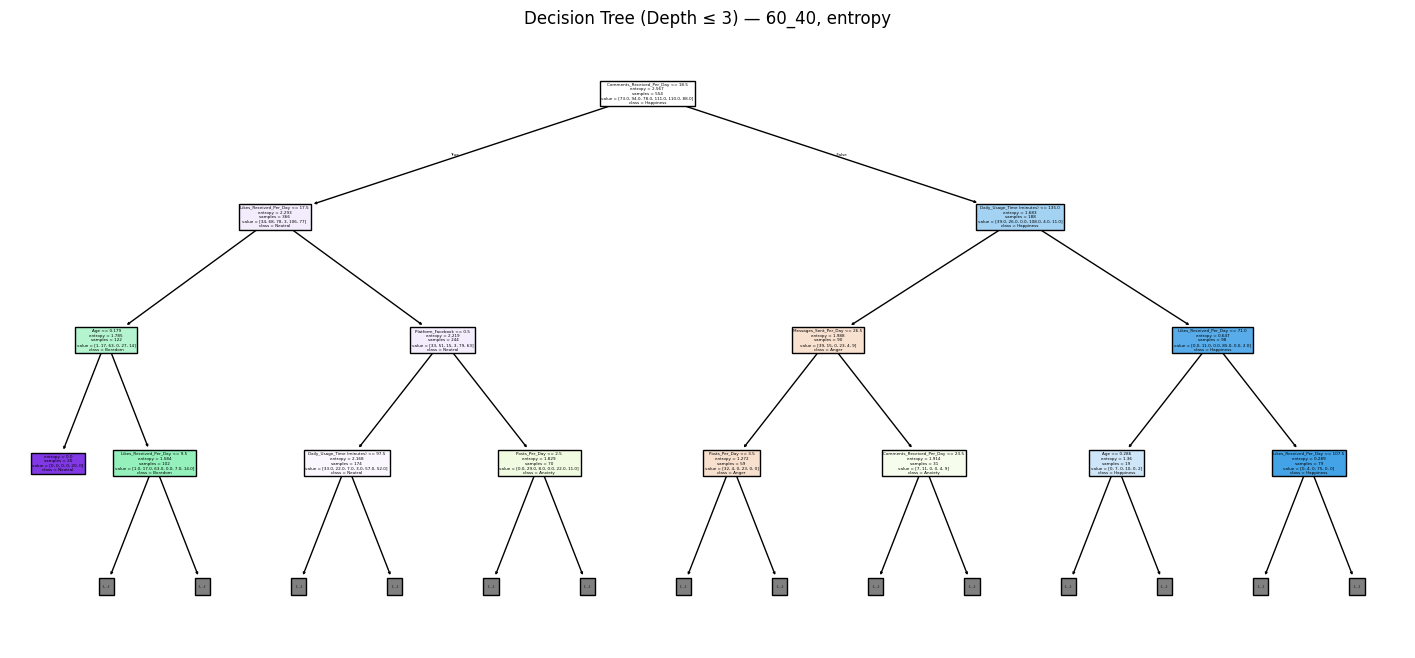


Split: 70_30 | Criterion: gini

Accuracy: 0.9532

Classification Report:
              precision    recall  f1-score   support

       Anger       1.00      0.97      0.99        37
     Anxiety       0.96      0.94      0.95        47
     Boredom       0.90      0.95      0.93        39
   Happiness       0.96      0.96      0.96        56
     Neutral       0.96      0.98      0.97        55
     Sadness       0.93      0.91      0.92        44

    accuracy                           0.95       278
   macro avg       0.95      0.95      0.95       278
weighted avg       0.95      0.95      0.95       278



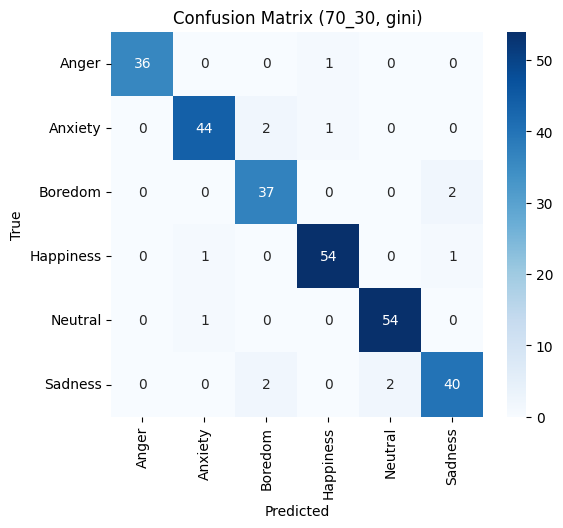

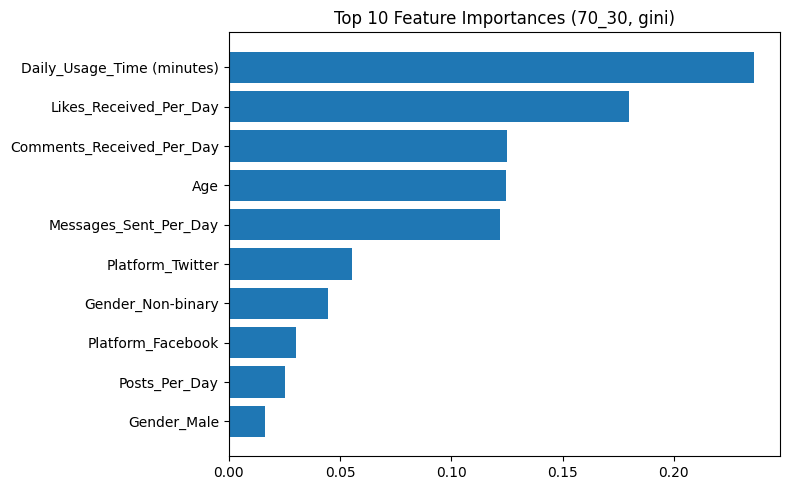

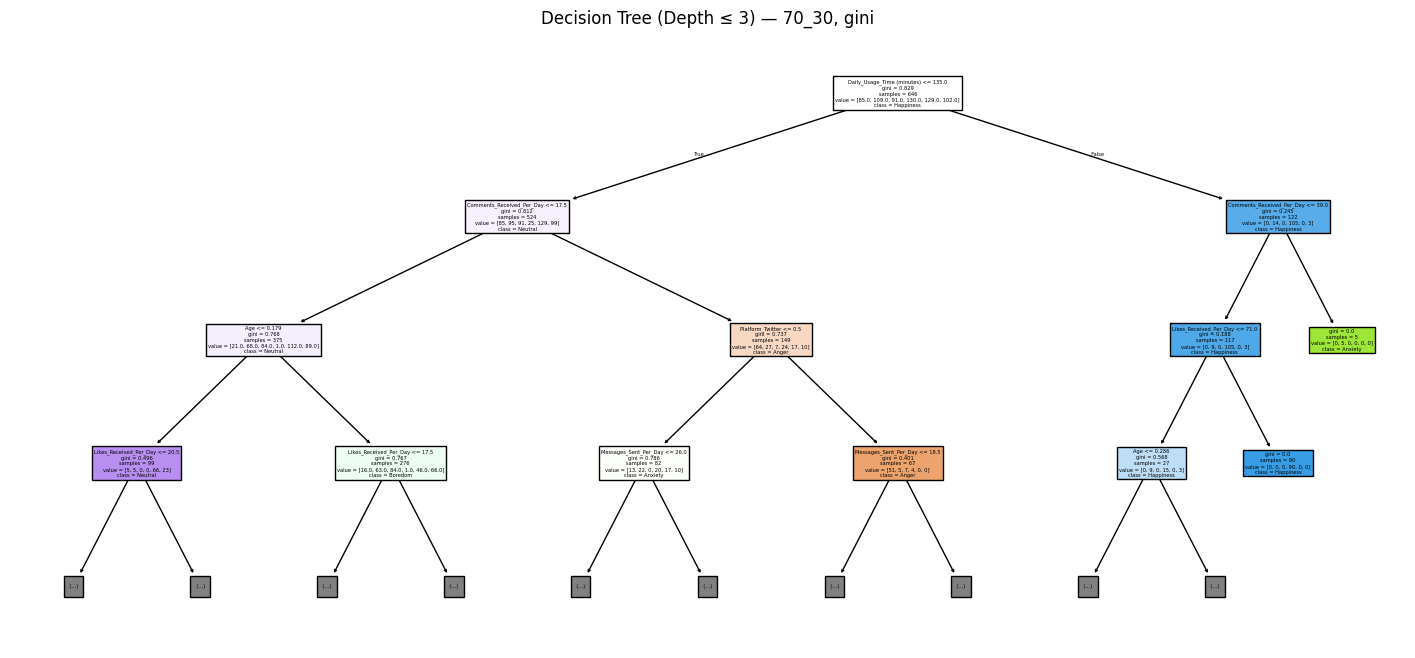


Split: 70_30 | Criterion: entropy

Accuracy: 0.9568

Classification Report:
              precision    recall  f1-score   support

       Anger       0.97      0.97      0.97        37
     Anxiety       0.98      0.91      0.95        47
     Boredom       0.91      1.00      0.95        39
   Happiness       0.98      0.95      0.96        56
     Neutral       0.95      1.00      0.97        55
     Sadness       0.95      0.91      0.93        44

    accuracy                           0.96       278
   macro avg       0.96      0.96      0.96       278
weighted avg       0.96      0.96      0.96       278



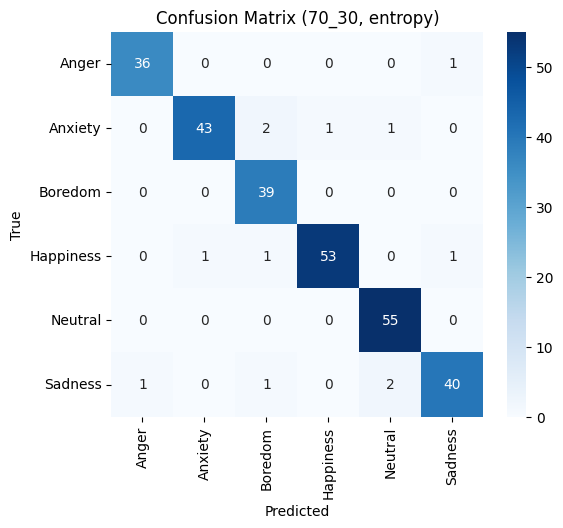

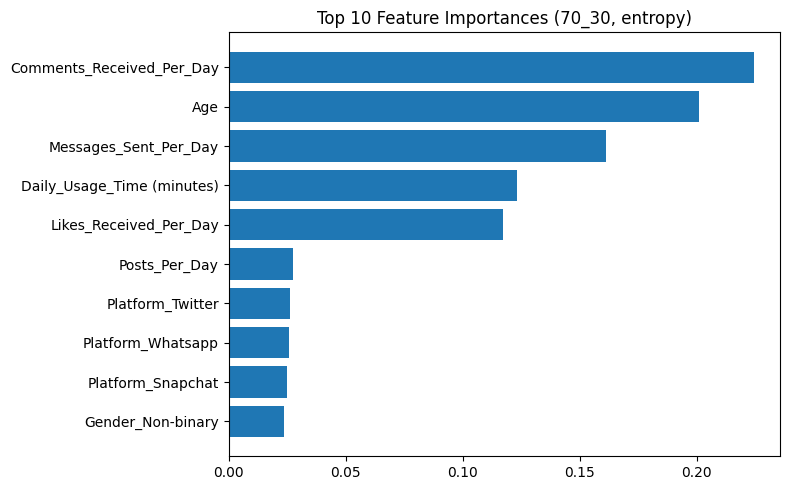

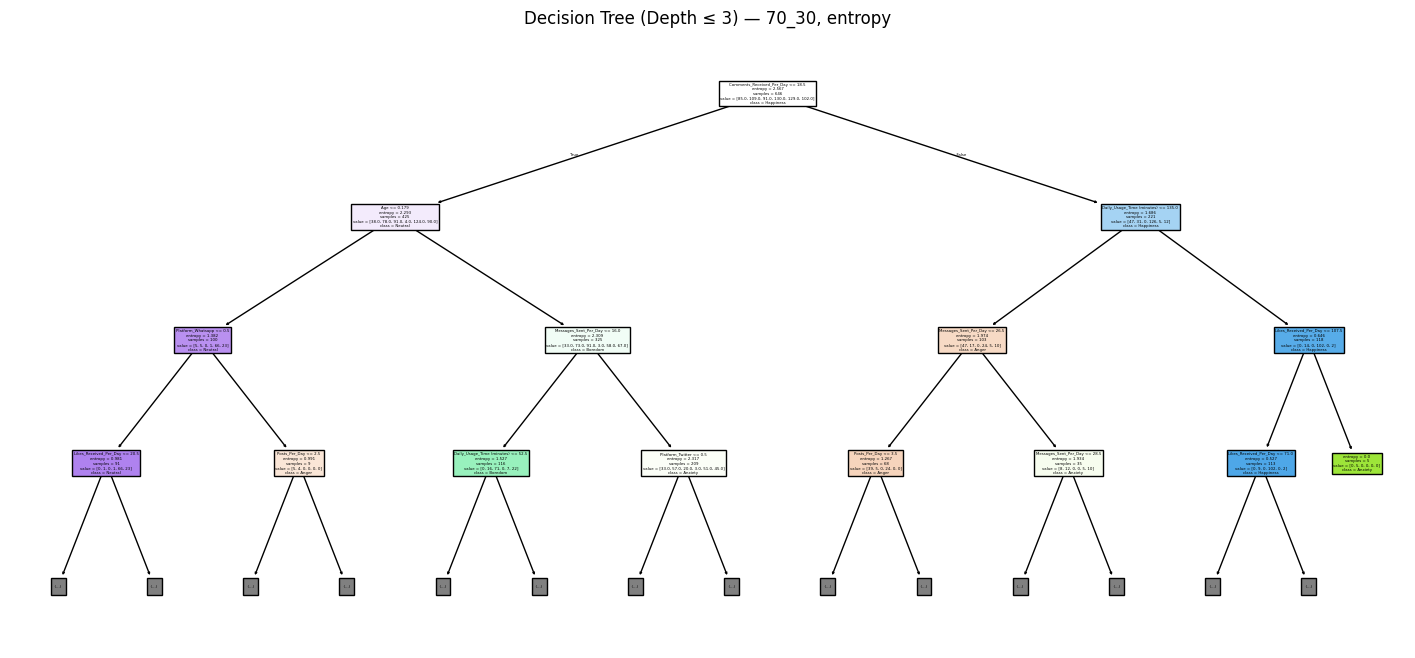


Split: 80_20 | Criterion: gini

Accuracy: 0.9730

Classification Report:
              precision    recall  f1-score   support

       Anger       1.00      0.96      0.98        25
     Anxiety       0.97      0.90      0.93        31
     Boredom       0.90      1.00      0.95        26
   Happiness       0.97      1.00      0.99        37
     Neutral       1.00      0.97      0.99        37
     Sadness       1.00      1.00      1.00        29

    accuracy                           0.97       185
   macro avg       0.97      0.97      0.97       185
weighted avg       0.97      0.97      0.97       185



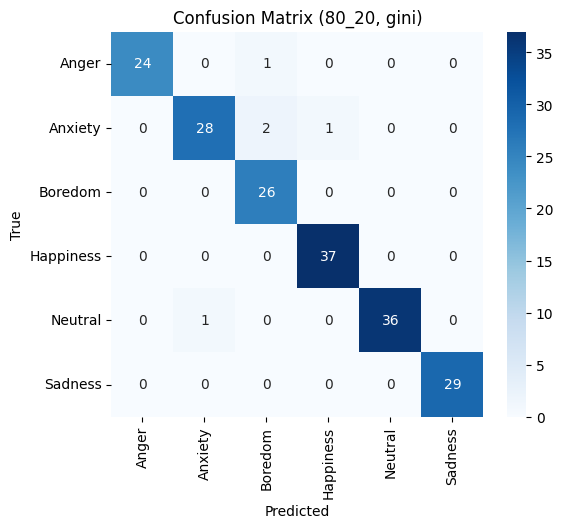

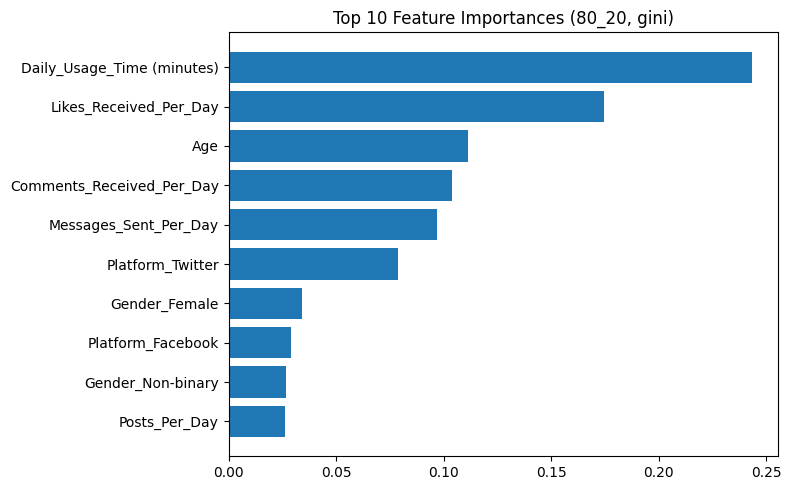

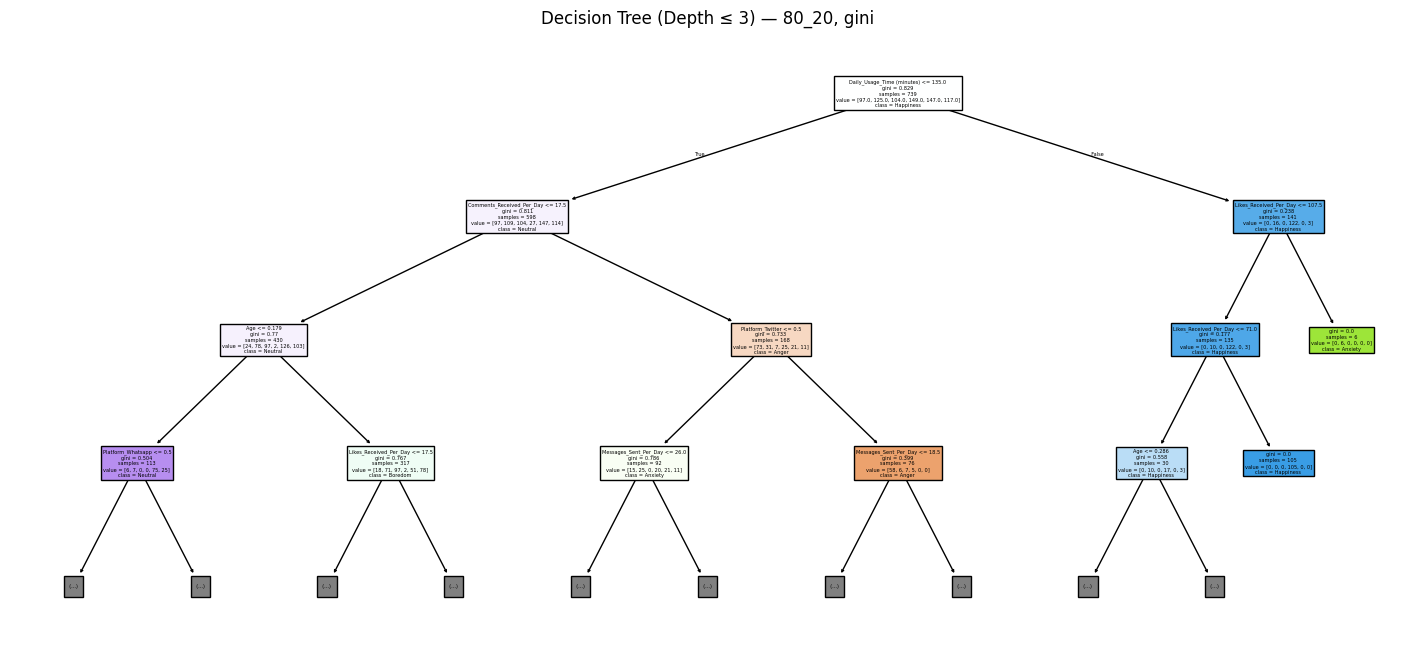


Split: 80_20 | Criterion: entropy

Accuracy: 0.9622

Classification Report:
              precision    recall  f1-score   support

       Anger       1.00      0.92      0.96        25
     Anxiety       0.94      0.97      0.95        31
     Boredom       0.96      1.00      0.98        26
   Happiness       1.00      0.95      0.97        37
     Neutral       0.97      0.97      0.97        37
     Sadness       0.90      0.97      0.93        29

    accuracy                           0.96       185
   macro avg       0.96      0.96      0.96       185
weighted avg       0.96      0.96      0.96       185



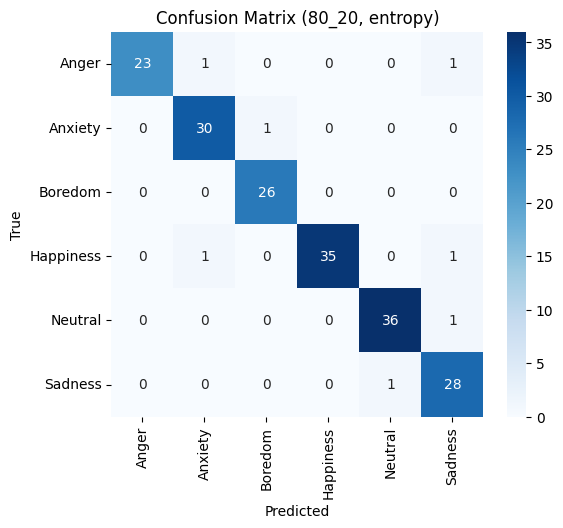

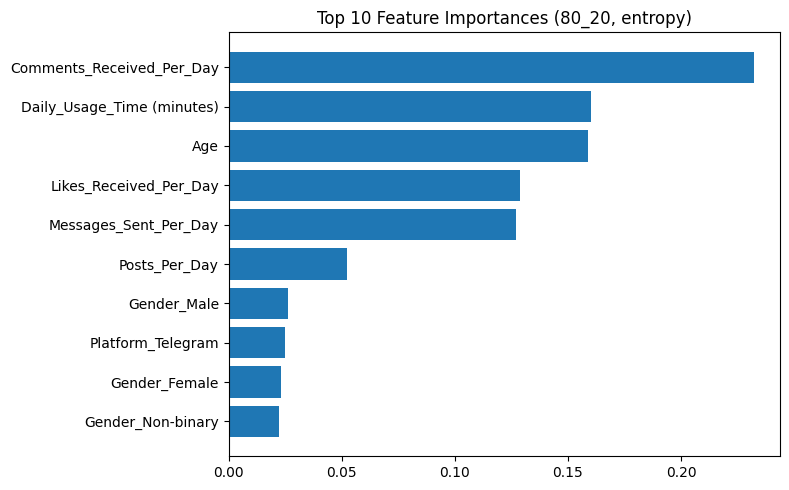

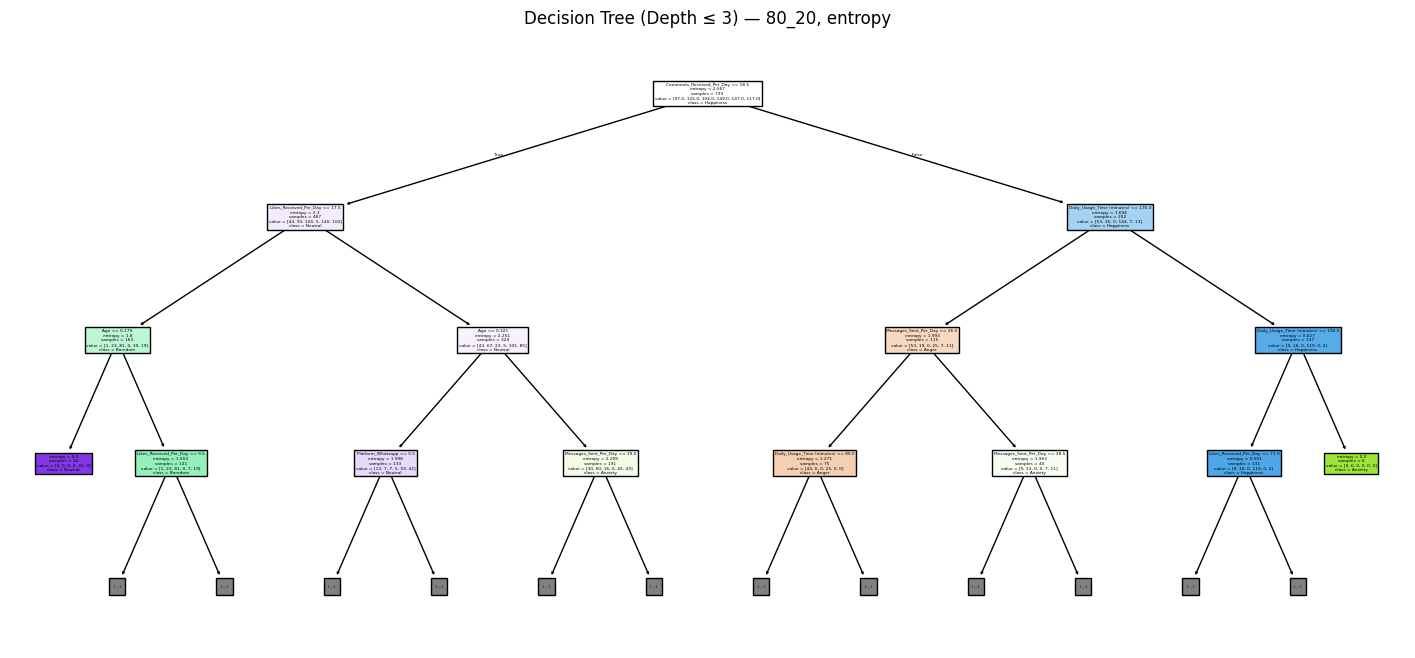

In [ ]:
for split_name, test_size in splits.items():
    for crit in criteria:
        print("\n=====================================")
        print(f"Split: {split_name} | Criterion: {crit}")
        print("=====================================\n")
        # Train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y_encoded, test_size=test_size, random_state=42, stratify=y_encoded
        )
        # Model
        model = DecisionTreeClassifier(criterion=crit, random_state=42)
        model.fit(X_train, y_train)
        # Prediction
        y_pred = model.predict(X_test)
        # Accuracy
        acc = accuracy_score(y_test, y_pred)
        print(f"Accuracy: {acc:.4f}")
        # Classification Report
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred, target_names=le.classes_))
        # ------------------------------
        # Confusion Matrix
        # ------------------------------
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(6,5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
        plt.title(f"Confusion Matrix ({split_name}, {crit})")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.show()
        # ------------------------------
        # Feature Importances
        # ------------------------------
        importances = model.feature_importances_
        idx = np.argsort(importances)[-10:] # top 10 features
        plt.figure(figsize=(8,5))
        plt.barh(np.array(X.columns)[idx], importances[idx])
        plt.title(f"Top 10 Feature Importances ({split_name}, {crit})")
        plt.tight_layout()
        plt.show()
        # ------------------------------
        # Decision Tree Visualization
        # ------------------------------
        plt.figure(figsize=(18,8))
        plot_tree(
            model,
            feature_names=X.columns,
            class_names=le.classes_,
            filled=True,
            max_depth=3
        )
        plt.title(f"Decision Tree (Depth ≤ 3) — {split_name}, {crit}")
        plt.show()

The Decision Tree models performed consistently well across all train–test splits (60/40, 70/30, 80/20) and using both Gini and Entropy criteria. Gini produced slightly simpler trees, while Entropy created deeper ones with similar accuracy. Visualizations showed that most classes were correctly predicted, with only small confusions between similar categories. Feature-importance plots revealed that a few key features strongly influenced predictions. Overall, the classifier showed stable, high performance and remained interpretable across all configurations.

# Clustering

## 1) Load the Preprocessed Dataset

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

df = pd.read_csv("Preprocessed_dataset.csv")

# حذف الكلاس ليبل
df_clustering = df.drop(columns=["Dominant_Emotion"])


## 3)Elbow Method
We tested K values from 2 to 9, calculated the Within-Cluster Sum of Squares (WCSS), and plotted the Elbow graph.
Elbow method helps identify where the decrease in WCSS becomes less significant, indicating a reasonable choice for K.

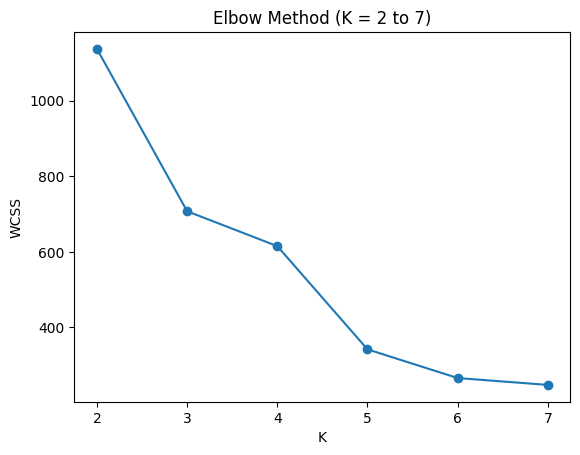

In [ ]:
wcss = []
K_range = range(2, 8)  # من 2 إلى 7

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_clustering)
    wcss.append(kmeans.inertia_)

plt.plot(K_range, wcss, marker='o')
plt.title("Elbow Method (K = 2 to 7)")
plt.xlabel("K")
plt.ylabel("WCSS")
plt.show()


## 4)Calculate Silhouette Score foe each k and Evaluation
We calculated the Silhouette Score for each value of K (from 2 to 7).
The Silhouette Score measures how well-separated and cohesive the clusters are.
Higher scores indicate better clustering quality.



In [ ]:
silhouette_scores = []

for k in K_range:  # نفس K_range = range(2, 7)
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_clustering)
    sil = silhouette_score(df_clustering, labels)
    silhouette_scores.append([k, sil])
    print(f"K = {k}, Silhouette = {sil:.4f}")


K = 2, Silhouette = 0.6147
K = 3, Silhouette = 0.5188
K = 4, Silhouette = 0.4541
K = 5, Silhouette = 0.5256
K = 6, Silhouette = 0.5412
K = 7, Silhouette = 0.5196


## 5)Final K Selection
Based on the Silhouette Score, K = 2 produced the best clustering performance with the highest score of 0.6147.
However, as required in the project, additional clustering configurations (K = 5 and K = 7) were also analyzed to provide a full comparison.

In [ ]:
k_list = [2, 5, 7]

for k in k_list:
    kmeans = KMeans(n_clusters=k, random_state=42)
    df[f"Cluster_{k}"] = kmeans.fit_predict(df_clustering)

    sil = silhouette_score(df_clustering, df[f"Cluster_{k}"])
    print(f"\nK = {k} → Silhouette = {sil:.4f}")
    print(df[f"Cluster_{k}"].value_counts())



K = 2 → Silhouette = 0.6147
Cluster_2
0    532
1    392
Name: count, dtype: int64

K = 5 → Silhouette = 0.5256
Cluster_5
1    256
4    236
2    186
0    178
3     68
Name: count, dtype: int64

K = 7 → Silhouette = 0.5196
Cluster_7
4    236
0    178
5    136
2    118
1    114
6     74
3     68
Name: count, dtype: int64


In [ ]:
df = pd.read_csv("Preprocessed_dataset.csv")

# نحذف فقط الكلاس
df_clustering = df.drop(columns=["Dominant_Emotion"])


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(df_clustering)
df["Cluster_2"] = clusters


## 6)1.Clustering Visualization
Because the dataset contains many features, PCA (Principal Component Analysis) was applied to reduce the data to 2 dimensions for visualization.
PCA allows us to visually distinguish clusters more clearly.

In [ ]:
from sklearn.cluster import KMeans

X = df.drop(columns=["Dominant_Emotion"])

for k in [2,5,7]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    df[f"Cluster_{k}"] = kmeans.fit_predict(X)


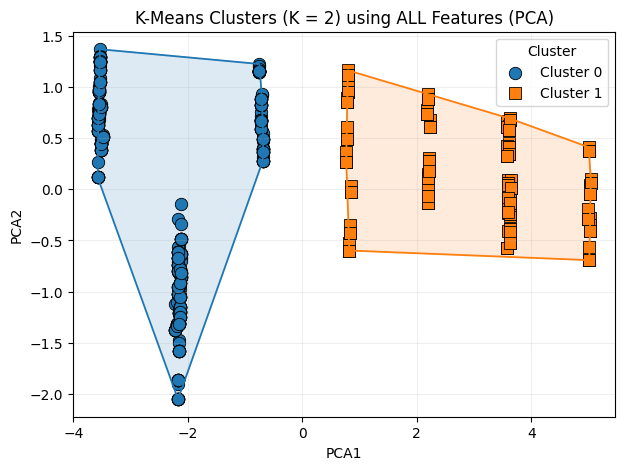

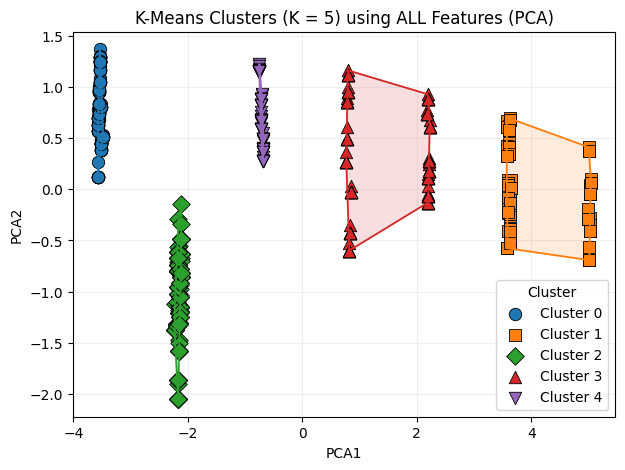

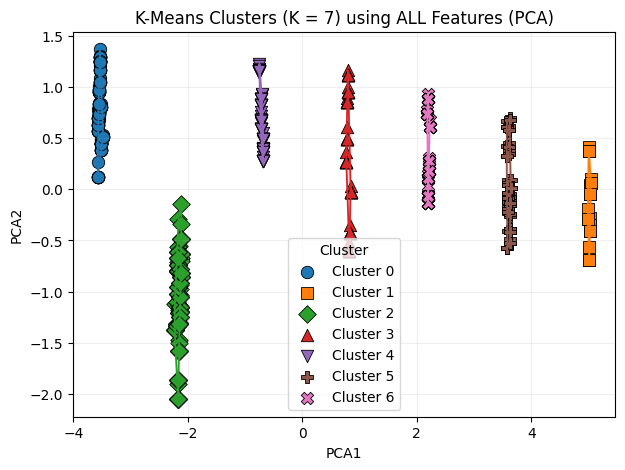

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial import ConvexHull   # مهم

k_values = [2, 5, 7]
markers = {0:"o", 1:"s", 2:"D", 3:"^", 4:"v", 5:"P", 6:"X"}
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2"]

for k in k_values:
    plt.figure(figsize=(7,5))
    labels = df[f"Cluster_{k}"]

    for cid in sorted(labels.unique()):
        subset = df[labels == cid]
        points = subset[["PCA1", "PCA2"]].values

        # لو الكلستر فيه أقل من 3 نقاط ما نقدر نسوي له مضلع
        if len(points) >= 3:
            hull = ConvexHull(points)
            hull_points = points[hull.vertices]

            # تعبئة المنطقة بلون خفيف
            plt.fill(
                hull_points[:,0],
                hull_points[:,1],
                color=colors[cid % len(colors)],
                alpha=0.15
            )

            # رسم حدود المضلع
            plt.plot(
                np.append(hull_points[:,0], hull_points[0,0]),
                np.append(hull_points[:,1], hull_points[0,1]),
                color=colors[cid % len(colors)],
                linewidth=1.3
            )

        # نقاط الكلستر نفسها
        plt.scatter(
            subset["PCA1"],
            subset["PCA2"],
            s=80,
            color=colors[cid % len(colors)],
            marker=markers.get(cid, "o"),
            edgecolors="black",
            linewidth=0.6,
            label=f"Cluster {cid}"
        )

    plt.title(f"K-Means Clusters (K = {k}) using ALL Features (PCA)")
    plt.xlabel("PCA1")
    plt.ylabel("PCA2")
    plt.legend(title="Cluster")
    plt.grid(alpha=0.2)
    plt.show()


### 2.Optimal K Selection Based on Visualization
Based on the PCA visualizations, K = 2 is the best choice because the two clusters are clearly separated with no overlap, and each cluster is compact and cohesive.
In contrast, K = 5 splits one natural group into smaller parts, and K = 7 produces fragmented and overlapping clusters.
Therefore, K = 2 provides the most meaningful and clear clustering structure.

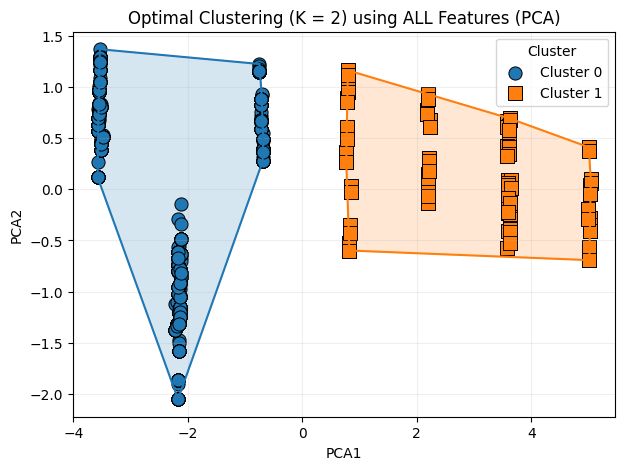

In [ ]:
optimal_k = 2
plt.figure(figsize=(7,5))
labels = df[f"Cluster_{optimal_k}"]

for cid in sorted(labels.unique()):
    subset = df[labels == cid]
    points = subset[["PCA1", "PCA2"]].values

    if len(points) >= 3:
        hull = ConvexHull(points)
        hull_points = points[hull.vertices]

        plt.fill(
            hull_points[:,0],
            hull_points[:,1],
            color=colors[cid % len(colors)],
            alpha=0.18
        )
        plt.plot(
            np.append(hull_points[:,0], hull_points[0,0]),
            np.append(hull_points[:,1], hull_points[0,1]),
            color=colors[cid % len(colors)],
            linewidth=1.5
        )

    plt.scatter(
        subset["PCA1"],
        subset["PCA2"],
        s=90,
        color=colors[cid % len(colors)],
        marker=markers.get(cid, "o"),
        edgecolors="black",
        linewidth=0.7,
        label=f"Cluster {cid}"
    )

plt.title(f"Optimal Clustering (K = {optimal_k}) using ALL Features (PCA)")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.legend(title="Cluster")
plt.grid(alpha=0.2)
plt.show()


## Clustering Evaluation: Silhouette Score and WCSS Comparison
To evaluate the quality of the clustering performance

· The silhouette score helped us determine how well-separated and cohesive our clusters were, with K=2 achieving the highest score of 0.7183, indicating clear and well-defined clusters.                                                                                
· The Elbow Method was used to identify the optimal number of clusters by plotting WCSS values for K ranging from 2 to 7. Although no sharp elbow was observed, the method confirmed that increasing K beyond 2 did not significantly improve cluster compactness.                                                                                                     
· K-means performed effectively on our social media usage dataset, with K=2 yielding the best results according to both silhouette score and WCSS metrics.                                                 
· However, cluster interpretation also depends on the nature of our dataset, as behavioral data related to social media usage may not form perfectly separated clusters due to gradual variations in user behavior patterns


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = [2, 5, 7]   # القيم اللي اشتغلنا عليها

cluster_results = {}

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)     # X = كل الأعمدة بدون Dominant_Emotion
    sil = silhouette_score(X, labels)
    wcss = kmeans.inertia_

    cluster_results[k] = {
        "silhouette": sil,
        "wcss": wcss
    }
print("Comparison of K values:\n")
for k in cluster_results.keys():
    print(f"K = {k}")
    print(f"  Silhouette Score: {cluster_results[k]['silhouette']:.4f}")
    print(f"  WCSS: {cluster_results[k]['wcss']:.2f}")
    print("-" * 30)


Comparison of K values:

K = 2
  Silhouette Score: 0.6522
  WCSS: 3008.70
------------------------------
K = 5
  Silhouette Score: 0.6513
  WCSS: 617.22
------------------------------
K = 7
  Silhouette Score: 0.6637
  WCSS: 360.73
------------------------------


### Cluster Interpretation for K = 2 (Aligned with Project Goal)
In this section, we analyze the two clusters generated using K = 2 to understand how users differ in their social media engagement levels.
The goal is to identify whether these behavioral differences relate to emotional well-being, which directly supports the project objective.
The interpretation is based on the average values of all features and the most significant differences between the two clusters.

In [ ]:
df["Cluster_2"] = KMeans(n_clusters=2, random_state=42).fit_predict(X)


In [ ]:
# ====== Cluster Interpretation for K = 2 (Linked to Project Goal) ======

df_comp = X.copy()  # X = all features without Dominant_Emotion
df_comp["Cluster"] = df["Cluster_2"]

cluster_profile = df_comp.groupby("Cluster").mean()
difference = (cluster_profile.loc[0] - cluster_profile.loc[1]).abs()

print("=== Cluster Profiles (Averages for Each Feature) ===\n")
print(cluster_profile)

print("\n=== Differences Between Clusters (Sorted) ===\n")
print(difference.sort_values(ascending=False))


# ======================
#  AUTO-GENERATED INTERPRETATION (English)
# ======================

print("\n\n================ CLUSTER INTERPRETATION (Connected to Project Goal) ================\n")

# Determine which cluster is higher in engagement
high_cluster = 0 if cluster_profile.loc[0].mean() > cluster_profile.loc[1].mean() else 1
low_cluster = 1 - high_cluster

print(f"Cluster {high_cluster} shows generally higher averages across most engagement features.\n")
print(f"Cluster {low_cluster} shows generally lower averages across most engagement features.\n")

print("Key features with the largest differences between the clusters:")
for feature, value in difference.sort_values(ascending=False).head(4).items():
    print(f"- {feature}: difference = {value:.4f}")

print("\n================ INTERPRETATION BASED ON PROJECT GOAL ================\n")

print(
f"Cluster {high_cluster} represents **High Social Media Engagement Users**, who spend more time online, send more messages, make more posts, "
"and receive more interactions. According to the project's goal—exploring the relationship between social media engagement and emotional well-being—"
"this group may be more exposed to emotional fluctuations such as anxiety, stress, or dependency due to their intensive usage patterns.\n"
)

print(
f"Cluster {low_cluster} represents **Low-to-Moderate Engagement Users**, who show more balanced and healthier usage behavior. "
"Based on emotional well-being literature, individuals with moderate social media use tend to experience more stable emotional states.\n"
)

print(
"These findings support the project’s main objective by showing that differences in engagement levels naturally separate users into two behavioral groups, "
"which may correlate with their emotional well-being patterns. Higher engagement may signal potential emotional risks, while moderate engagement is linked "
"to better emotional balance.\n"
)

print("================ END OF ANALYSIS ================")


=== Cluster Profiles (Averages for Each Feature) ===

              Age    Gender  Platform  Daily_Usage_Time (minutes)  \
Cluster                                                             
0        0.483888  0.471805  0.887218                    0.404370   
1        0.437682  0.415816  4.653061                    0.280772   

         Posts_Per_Day  Likes_Received_Per_Day  Comments_Received_Per_Day  \
Cluster                                                                     
0             0.360902                0.379860                   0.371092   
1             0.301385                0.275729                   0.347811   

         Messages_Sent_Per_Day  Cluster_2      PCA1      PCA2  
Cluster                                                        
0                     0.363946        0.0 -2.299276 -0.057807  
1                     0.325194        1.0  3.120447  0.078452  

=== Differences Between Clusters (Sorted) ===

PCA1                          5.419723
Platform         

In [ ]:
from sklearn.decomposition import PCA

# نحدد الأعمدة الرقمية فقط (كل الأعمدة ما عدا الكلاس)
features = df.drop(columns=["Dominant_Emotion"])

pca = PCA(n_components=2)
pca_result = pca.fit_transform(features)

df["PCA1"] = pca_result[:, 0]
df["PCA2"] = pca_result[:, 1]


# Report

## Problem

Many individuals use social media daily without realizing its emotional impact. Excessive or unbalanced usage can lead to anxiety, sadness, boredom, and other negative states. The lack of awareness and early detection makes it harder to intervene before emotional distress escalates. This project tackles the problem by using data mining to identify risky usage patterns and predict emotional outcomes.



## Data Mining Task

This project applies two main data mining tasks:

**Classification Task:**
The goal is to predict the user's dominant emotional state (Dominant_Emotion), which includes categories like Happiness, Sadness, Anger, Anxiety, Boredom, and Neutral. This is a multi-class classification problem where we aim to classify individuals based on their social media usage patterns—such as time spent, posts per day, likes, comments, and platform used. By doing so, we can identify users at risk of negative emotional states and support early awareness and intervention.


**Clustering Task:**
This task aims to group users into clusters based on similarities in their social media behavior and engagement metrics. By analyzing features like usage time, interaction levels, and platform preferences, clustering helps uncover hidden subgroups—such as highly active users, passive users, or emotionally vulnerable groups. These insights can guide personalized recommendations and mental health strategies.


## Data Understanding
Description of the dataset, features, and initial observations

Dataset name :Social Media Usage and Emotional Well-Being.

Dataset Source : Kaggle

URL: https://www.kaggle.com/datasets/emirhanai/social-media-usage-and-emotional-well-being

Step A: Importing the dataset - Reading from local file...
Path to dataset file: https://raw.githubusercontent.com/WajdAlSuhaymi/IT326-DataMining-Group2/main/Dataset/Raw_dataset.csv
Dataset loaded successfully.

Step B: Understanding the Dataset
The dataset consists of rows and columns containing various features related to social media usage and emotional well-being.
Rows: 924, Columns: 10
Column names: ['User_ID', 'Age', 'Gender', 'Platform', 'Daily_Usage_Time (minutes)', 'Posts_Per_Day', 'Likes_Received_Per_Day', 'Comments_Received_Per_Day', 'Messages_Sent_Per_Day', 'Dominant_Emotion']

Data Types of Columns:
User_ID                       float64
Age                           float64
Gender                         object
Platform                       object
Daily_Usage_Time (minutes)    float64
Posts_Per_Day                 float64
Likes_Received_Per_Day        float64
Comments_Received_Per_Day     float64
Messages_Sent_Per_Day         float64
Dominant_Emotion               object


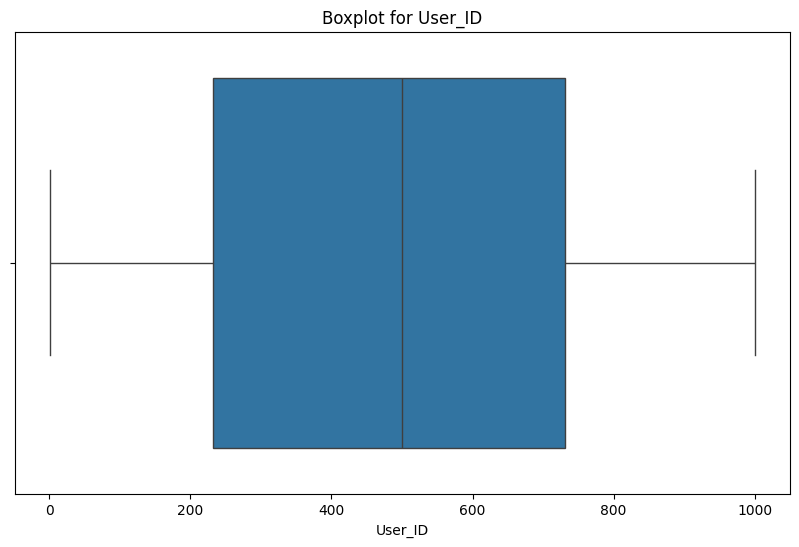

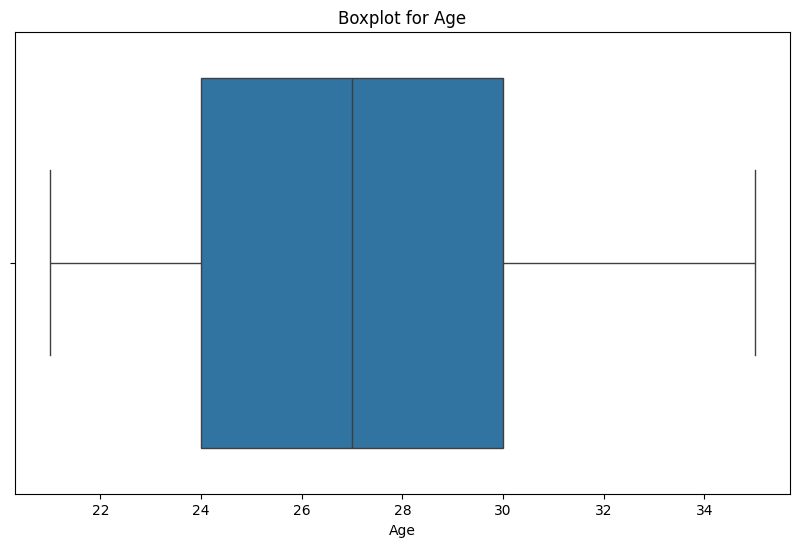

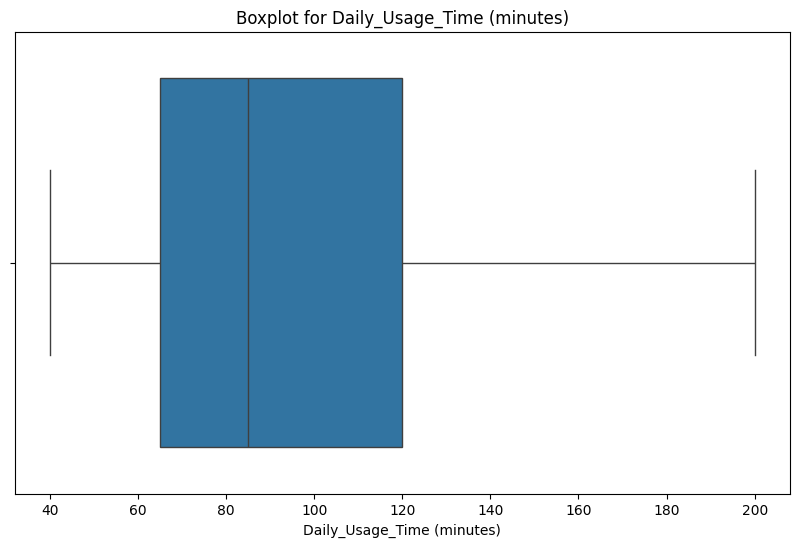

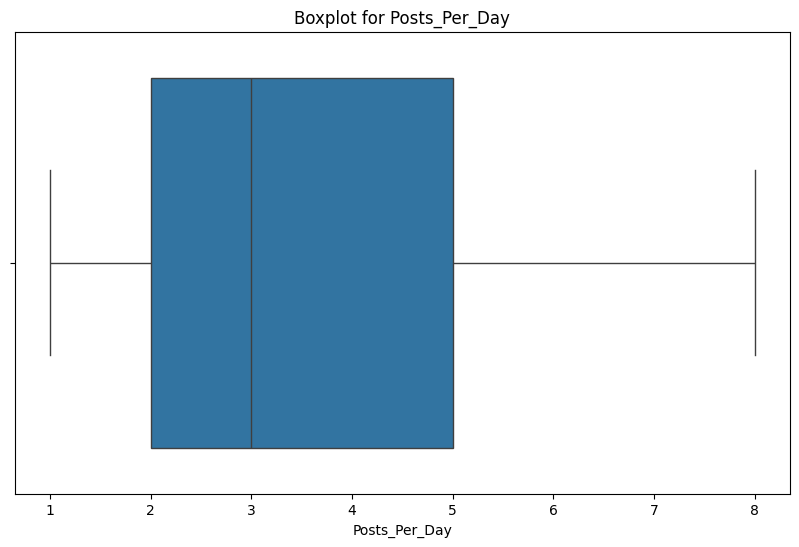

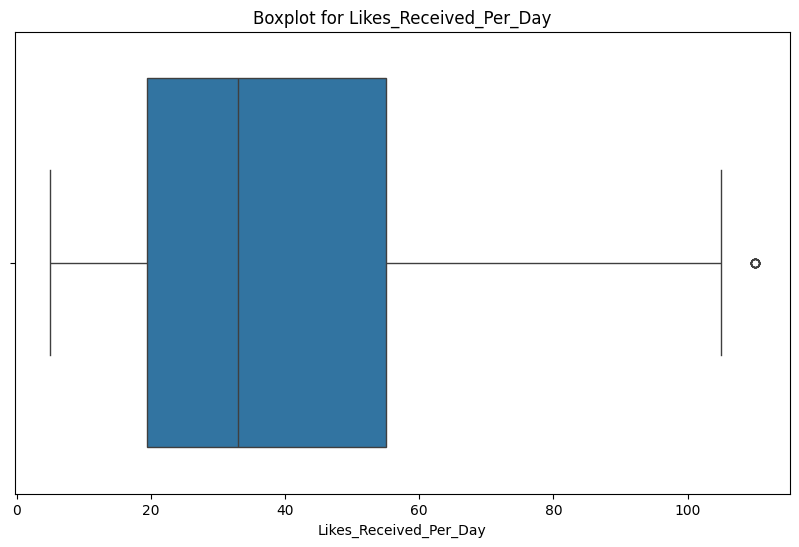

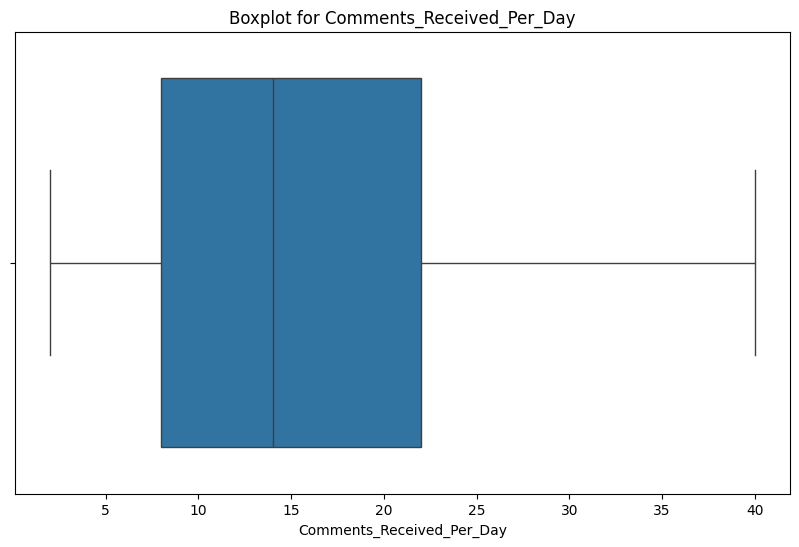

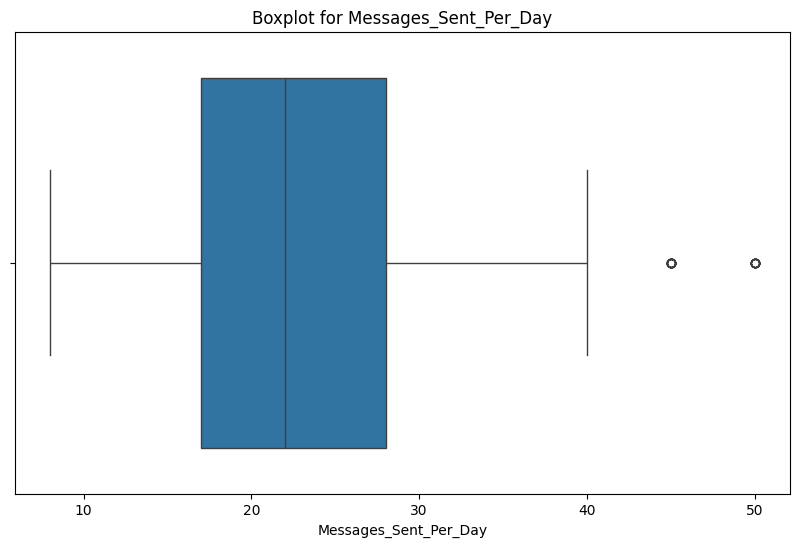


Step E: Data Visualization
Generating plots to understand feature distributions and relationships.

1. Histogram for Daily Usage Time:


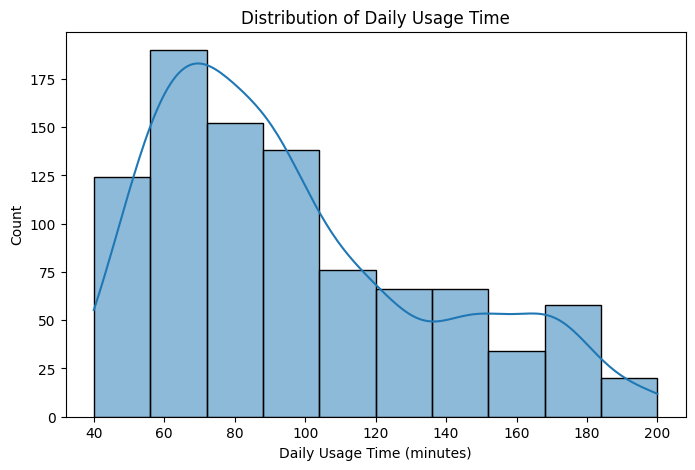

This histogram shows the distribution of daily social media usage time across the dataset. It helps understand user engagement patterns and identify common usage durations.

2. Bar Plot for Dominant Emotion Distribution:


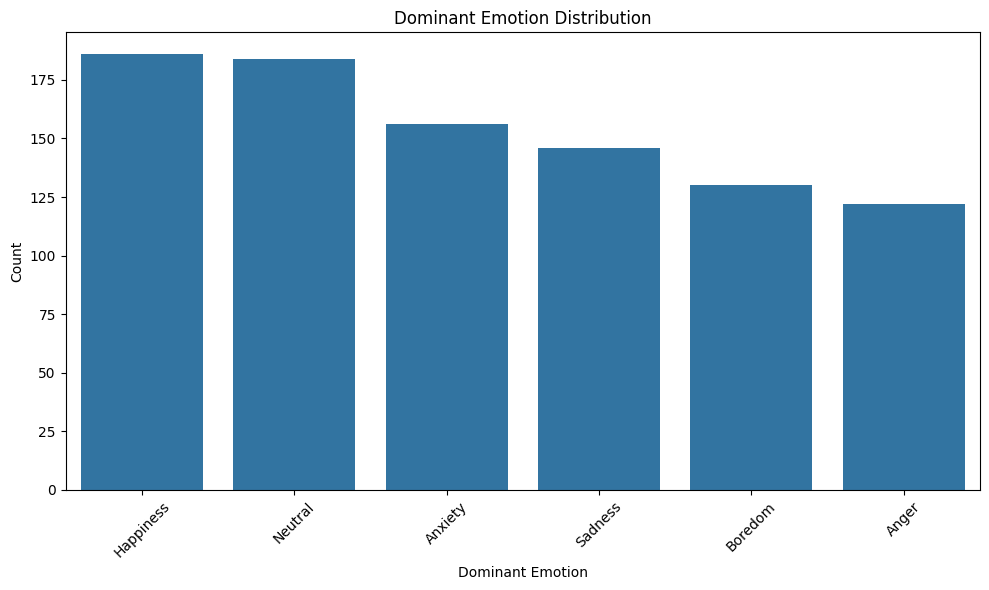

This bar plot shows the distribution of dominant emotions in the dataset. It's a nominal variable, and the count plot allows us to see the frequency of each emotional state among users.

3. Scatter Plot for Daily Usage Time vs Likes Received:


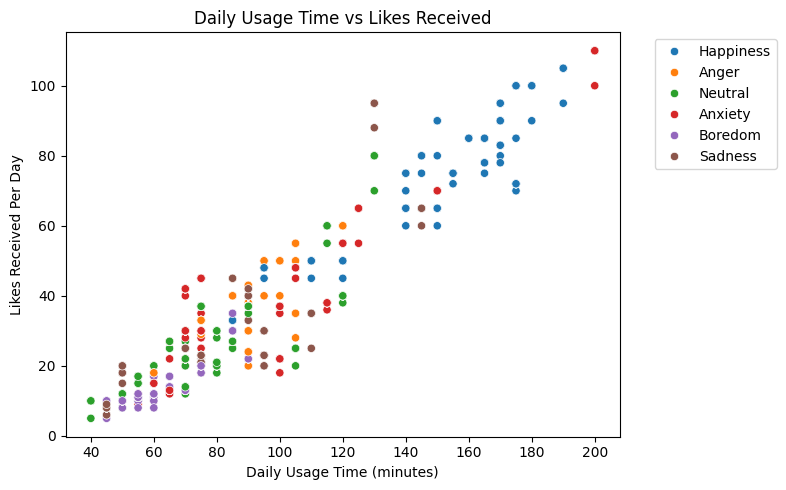

This scatter plot helps visualize the relationship between daily usage time and likes received.It can help identify any trends or patterns that might suggest a correlation between social media engagement and emotional states.

4. Correlation Heatmap of Numeric Features:


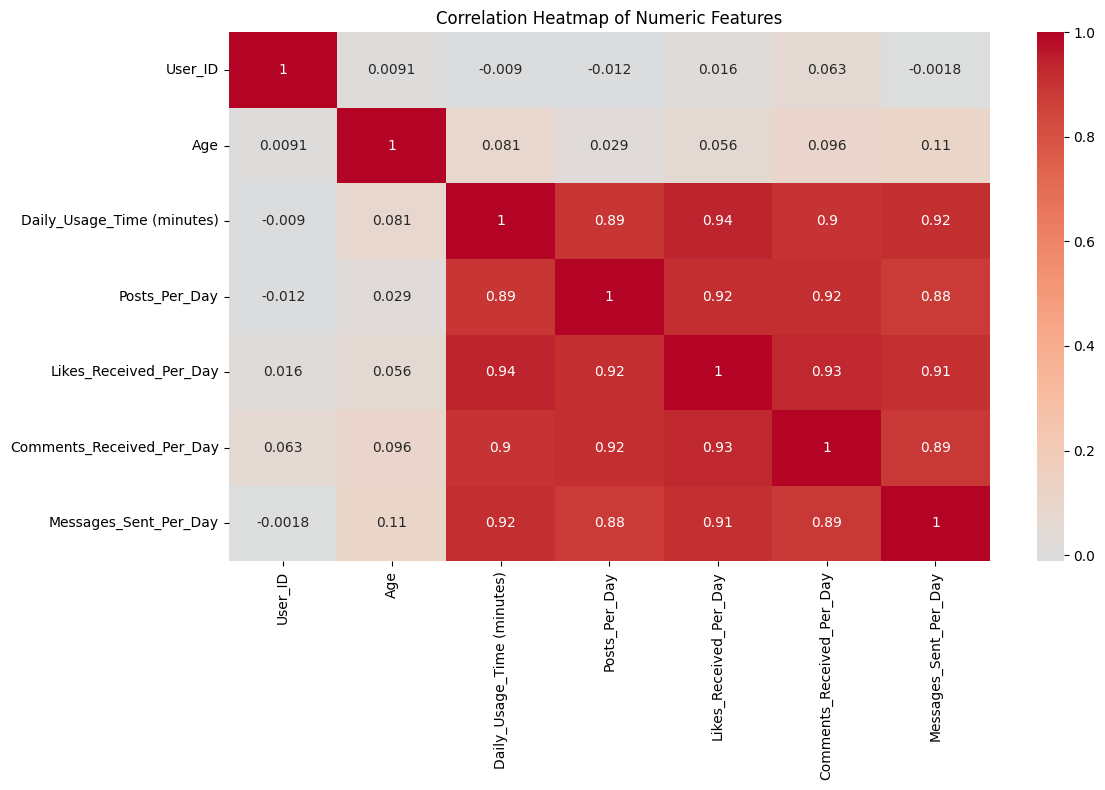

This heatmap shows the correlation between all numeric features. Strong correlations (close to 1 or -1) indicate relationships that might be important for our data mining tasks.

Concluding Observations from the Plots and Data Exploration:
From the above visualizations and statistical summaries, we can observe the following:
- The Dominant_Emotion distribution shows a relatively balanced dataset with Happiness and Neutral being the most common emotions.
- The Daily_Usage_Time distribution appears to have a normal distribution with some users showing extremely high usage patterns.
- The scatter plot between Daily_Usage_Time and Likes_Received_Per_Day suggests a positive correlation, indicating that active users tend to receive more engagement.
- The correlation heatmap reveals strong relationships between engagement metrics (Likes, Comments, Messages) and usage time.
- There are several potential outliers detected in engagement metrics that need to be addressed for better model performa

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Step A: Import the dataset
print("Step A: Importing the dataset - Reading from local file...")
dataset_path = 'https://raw.githubusercontent.com/WajdAlSuhaymi/IT326-DataMining-Group2/main/Dataset/Raw_dataset.csv'
print("Path to dataset file:", dataset_path)

def load_dataset():
    try:
        data = pd.read_csv(dataset_path)
        print("Dataset loaded successfully.")
        return data
    except FileNotFoundError:
        print(f"Could not find the dataset at: {dataset_path}. Please check the file name and path.")
        return None

data = load_dataset()

if data is not None:
    # Step B: Dataset Overview
    print("\nStep B: Understanding the Dataset")
    print("The dataset consists of rows and columns containing various features related to social media usage and emotional well-being.")
    print(f"Rows: {data.shape[0]}, Columns: {data.shape[1]}")
    print("Column names:", data.columns.tolist())

    # Data types of the columns
    print("\nData Types of Columns:")
    print(data.dtypes)

    # Missing values
    print("\nMissing Values in Each Column:")
    print(data.isnull().sum())

    # Step C: Statistical Summary (Five-number summary, including outliers)
    print("\nStep C: Statistical Summary")
    print("We calculate statistical measures such as mean, variance, and percentiles to understand data distribution.")
    print(data.describe())

    # Step D: Class Label Distribution (Detect Class Imbalance)
    print("\nStep D: Analyzing Class Distribution")
    print("Checking the distribution of the class label to detect any imbalances in the dataset.")
    print(data['Dominant_Emotion'].value_counts())

    # Boxplot for numeric features to visualize potential outliers
    print("\nVisualizing Numeric Features with Boxplots:")
    numeric_cols = data.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(x=data[col])
        plt.title(f'Boxplot for {col}')
        plt.xlabel(col)
        plt.show()

    # Step E: Data Visualization - Variable Distributions
    print("\nStep E: Data Visualization")
    print("Generating plots to understand feature distributions and relationships.")

    # 1. Histogram for Daily Usage Time (numeric attribute)
    print("\n1. Histogram for Daily Usage Time:")
    plt.figure(figsize=(8, 5))
    sns.histplot(data['Daily_Usage_Time (minutes)'], bins=10, kde=True)
    plt.title('Distribution of Daily Usage Time')
    plt.xlabel('Daily Usage Time (minutes)')
    plt.ylabel('Count')
    plt.show()
    print("This histogram shows the distribution of daily social media usage time across the dataset. It helps understand user engagement patterns and identify common usage durations.")

    # 2. Bar plot for Dominant Emotion (nominal attribute)
    print("\n2. Bar Plot for Dominant Emotion Distribution:")
    plt.figure(figsize=(10, 6))
    sns.countplot(x='Dominant_Emotion', data=data, order=data['Dominant_Emotion'].value_counts().index)
    plt.title('Dominant Emotion Distribution')
    plt.xlabel('Dominant Emotion')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    print("This bar plot shows the distribution of dominant emotions in the dataset. It's a nominal variable, and the count plot allows us to see the frequency of each emotional state among users.")

    # 3. Scatter plot for Daily Usage Time vs Likes Received (numeric attributes)
    print("\n3. Scatter Plot for Daily Usage Time vs Likes Received:")
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=data['Daily_Usage_Time (minutes)'], y=data['Likes_Received_Per_Day'], hue=data['Dominant_Emotion'])
    plt.title('Daily Usage Time vs Likes Received')
    plt.xlabel('Daily Usage Time (minutes)')
    plt.ylabel('Likes Received Per Day')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    print("This scatter plot helps visualize the relationship between daily usage time and likes received.It can help identify any trends or patterns that might suggest a correlation between social media engagement and emotional states.")

    # 4. Correlation Heatmap
    print("\n4. Correlation Heatmap of Numeric Features:")
    plt.figure(figsize=(12, 8))
    numeric_data = data.select_dtypes(include=[np.number])
    correlation_matrix = numeric_data.corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
    plt.title('Correlation Heatmap of Numeric Features')
    plt.tight_layout()
    plt.show()
    print("This heatmap shows the correlation between all numeric features. Strong correlations (close to 1 or -1) indicate relationships that might be important for our data mining tasks.")

    print("\nConcluding Observations from the Plots and Data Exploration:")
    print("From the above visualizations and statistical summaries, we can observe the following:")
    print("- The Dominant_Emotion distribution shows a relatively balanced dataset with Happiness and Neutral being the most common emotions.")
    print("- The Daily_Usage_Time distribution appears to have a normal distribution with some users showing extremely high usage patterns.")
    print("- The scatter plot between Daily_Usage_Time and Likes_Received_Per_Day suggests a positive correlation, indicating that active users tend to receive more engagement.")
    print("- The correlation heatmap reveals strong relationships between engagement metrics (Likes, Comments, Messages) and usage time.")
    print("- There are several potential outliers detected in engagement metrics that need to be addressed for better model performance.")
    print("Based on these insights, it is clear that the dataset is well-suited for both classification (predicting emotions) and clustering (grouping similar users) tasks.")


## Data Preprocessing
Summary of the cleaning, encoding, normalization, and feature preparation steps
Preprocessing Steps:

Removed irrelevant columns

Encoded Dominant_Emotion into numeric Emotion_Score

Normalized numerical features

Removed missing values

Prepared df_cluster for unsupervised learning

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

# ==========================
# Load the dataset
# ==========================
dataset_path = "https://raw.githubusercontent.com/WajdAlSuhaymi/IT326-DataMining-Group2/main/Dataset/Raw_dataset.csv"
df = pd.read_csv(dataset_path)

# Drop any completely empty rows (safety check)
df = df.dropna(how='all')

# Create a copy for preprocessing
df_processed = df.copy()

# ==========================
# Intro: Why Apply Data Preprocessing?
# ==========================
print("Why Apply Data Preprocessing?\n")
print("Data preprocessing is a crucial step in data mining and machine learning as it ensures that the dataset is clean,")
print("consistent, and ready for analysis or model training.")
print("Raw data may contain issues such as missing values, inconsistent data types, and features with different scales,")
print("all of which can negatively impact the performance and reliability of the results.\n")

print("In this project, we preprocess the Social Media Usage and Emotional Well-Being dataset using the following steps:\n")
print("1. Handling Missing Values in numeric features using the MEAN of each column.")
print("2. Age Grouping (Binning) for descriptive analysis (not added as a new column).")
print("3. Categorical Encoding for 'Gender' and 'Platform' using Label Encoding.")
print("4. Normalization (Min-Max Scaling) for selected numeric features (including Age and Gender).")
print("   The target variable 'Dominant_Emotion' is kept unchanged as the class label.\n")

# Snapshot of raw dataset
print("Raw Dataset Snapshot:")
print(df.head(), "\n")

# ==========================
# Step 1: Handling Missing Values (Numeric Columns)
# ==========================
print("Step 1: Handling Missing Values (Numeric Columns)")
print("We will convert selected features to numeric and fill missing values with the MEAN of each column.\n")

# Define numeric columns (same as in your original code)
numeric_cols = [
    "Age",
    "Daily_Usage_Time (minutes)",
    "Posts_Per_Day",
    "Likes_Received_Per_Day",
    "Comments_Received_Per_Day",
    "Messages_Sent_Per_Day"
]

# Convert to numeric (just in case there are non-numeric values)
df_processed[numeric_cols] = df_processed[numeric_cols].apply(pd.to_numeric, errors='coerce')

print("Missing values before handling (df_processed):")
print(df_processed[numeric_cols].isnull().sum(), "\n")

# Fill missing numeric values with the mean of each column
for col in numeric_cols:
    df_processed[col] = df_processed[col].fillna(df_processed[col].mean())

print("Missing values after handling (df_processed):")
print(df_processed[numeric_cols].isnull().sum(), "\n")
print("✔ Numeric columns cleaned and missing values filled using MEAN.\n")

# ==========================
# Step 2: Age Binning (For Analysis Only)
# ==========================
print("Step 2: Age Grouping (Binning) for Descriptive Analysis")
print("We create age groups based on the REAL Age column, but we DO NOT add them as a new feature in the dataset.")
print("This step is only used to describe the age distribution in the report.\n")

bins = [20, 25, 30, 35]
labels = ['21–25', '26–30', '31–35']

age_binned_temp = pd.cut(df_processed["Age"], bins=bins, labels=labels, include_lowest=True)

print("Age Group Distribution (for analysis only):")
print(age_binned_temp.value_counts(), "\n")
print("✔ Age binning completed (not stored as a column).\n")

# ==========================
# Step 3: Categorical Encoding (Label Encoding)
# ==========================
print("Step 3: Categorical Encoding (Label Encoding)")
print("We apply Label Encoding on 'Gender' and 'Platform' so they can be used as numeric features.\n")

label_cols = ["Gender", "Platform"]
label_encoders = {}

for col in label_cols:
    if col in df_processed.columns:
        le = LabelEncoder()
        df_processed[col] = le.fit_transform(df_processed[col].astype(str))
        label_encoders[col] = le
        print(f"Encoded {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print("\nEncoded Categorical Features (head):")
print(df_processed[label_cols].head(), "\n")
print("✔ Label encoding applied on Gender and Platform.\n")

# ==========================
# Step 4: Normalization (Min-Max Scaling)
# ==========================
print("Step 4: Normalization (Min-Max Scaling)")
print("We apply Min-Max scaling to selected numeric features so that all values fall in the range [0, 1].")
print("This helps clustering algorithms treat all features fairly regardless of their original units.\n")

numeric_to_scale = [
    "Age",
    "Daily_Usage_Time (minutes)",
    "Posts_Per_Day",
    "Likes_Received_Per_Day",
    "Comments_Received_Per_Day",
    "Messages_Sent_Per_Day",
    "Gender"  # Gender is now numeric and included in scaling as in your original code
]

scaler = MinMaxScaler()
df_processed[numeric_to_scale] = scaler.fit_transform(df_processed[numeric_to_scale])

print("Normalized Numerical Features (head):")
print(df_processed[numeric_to_scale].head(), "\n")
print("✔ Normalization applied on selected numeric columns (including Age & Gender).\n")

# ==========================
# Step 5: Remove User_ID (if exists)
# ==========================
print("Step 5: Removing 'User_ID' (if exists)")
if "User_ID" in df_processed.columns:
    df_processed = df_processed.drop(columns=["User_ID"])
    print("✔ 'User_ID' column removed from df_processed.\n")
else:
    print("ℹ 'User_ID' not found in df_processed. No column removed.\n")

# ==========================
# Step 6: Final Summary & Saving the Dataset
# ==========================
print("Step 6: Preprocessing Summary")
print("=" * 60)
print(f"Final dataset shape: {df_processed.shape}")
print(f"Numeric features normalized: {len(numeric_to_scale)}")
print(f"Categorical features encoded: {len(label_cols)}")
print(f"Total missing values after preprocessing: {df_processed.isnull().sum().sum()}")

print("\nPreprocessed Dataset Snapshot:")
print(df_processed.head())

# If Dominant_Emotion exists, show its class distribution
if "Dominant_Emotion" in df_processed.columns:
    print("\nClass Distribution of 'Dominant_Emotion' After Preprocessing:")
    print(df_processed["Dominant_Emotion"].value_counts())

# Save the preprocessed dataset (same name you used before)
output_filename = "Preprocessed_dataset.csv"
df_processed.to_csv(output_filename, index=False)
print(f"\nPreprocessed dataset saved as '{output_filename}'")

print("\nConclusion:")
print("The dataset has been successfully preprocessed with the following transformations:")
print(" Missing numeric values handled using the MEAN of each column")
print(" Age groups generated for descriptive analysis (not added as a feature)")
print("'Gender' and 'Platform' encoded using Label Encoding")
print(" Selected numeric features normalized to [0, 1] using Min-Max Scaling")
print(" The dataset is now ready for data mining techniques such as clustering and classification.")


Why Apply Data Preprocessing?

Data preprocessing is a crucial step in data mining and machine learning as it ensures that the dataset is clean,
consistent, and ready for analysis or model training.
Raw data may contain issues such as missing values, inconsistent data types, and features with different scales,
all of which can negatively impact the performance and reliability of the results.

In this project, we preprocess the Social Media Usage and Emotional Well-Being dataset using the following steps:

1. Handling Missing Values in numeric features using the MEAN of each column.
2. Age Grouping (Binning) for descriptive analysis (not added as a new column).
3. Categorical Encoding for 'Gender' and 'Platform' using Label Encoding.
4. Normalization (Min-Max Scaling) for selected numeric features (including Age and Gender).
   The target variable 'Dominant_Emotion' is kept unchanged as the class label.

Raw Dataset Snapshot:
   User_ID   Age      Gender   Platform  Daily_Usage_Time (mi

## Data Mining Technique
Explanation of the classification algorithms, clustering approach, and rationale for technique selection.

5. Data Mining Technique – Classification

Why Classification?
Build a classification model to predict users' dominant emotional states (Happiness, Anger, Neutral, Anxiety, Boredom, Sadness) based on their social media behavior patterns.
- Enables understanding of how social media usage correlates with emotional well-being
- Helps identify key behavioral indicators of different emotional states
- Supports mental health professionals in detecting potential emotional issues through digital behavior

Applied Methodology:
- Used Decision Tree Classifier for its interpretability and ability to handle mixed data types
- Utilized all preprocessed features from Preprocessed_dataset.csv
- Split data into training/testing sets with three different partitions (60-40, 70-30, 80-20)
- Tested two attribute selection measures: Gini Index and Information Gain (Entropy)

Evaluation Metrics:
- Accuracy: Overall correctness of predictions
- Precision: Accuracy of positive predictions for each emotion cla

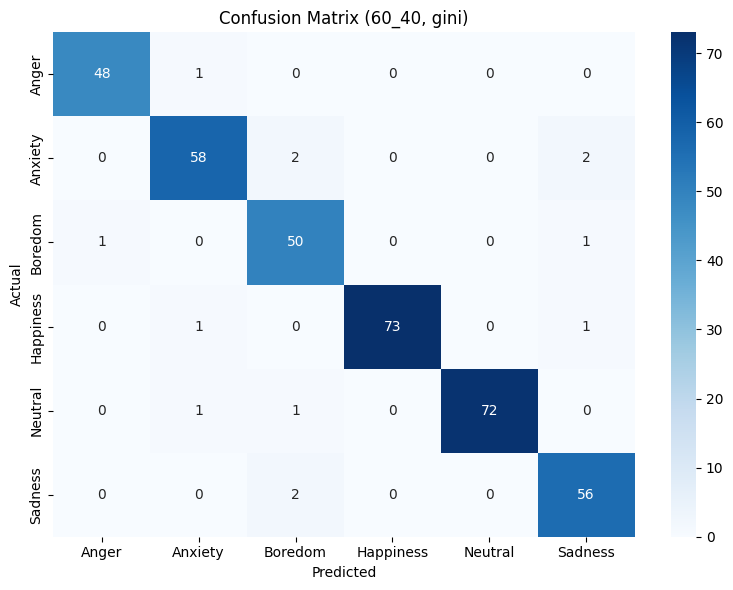

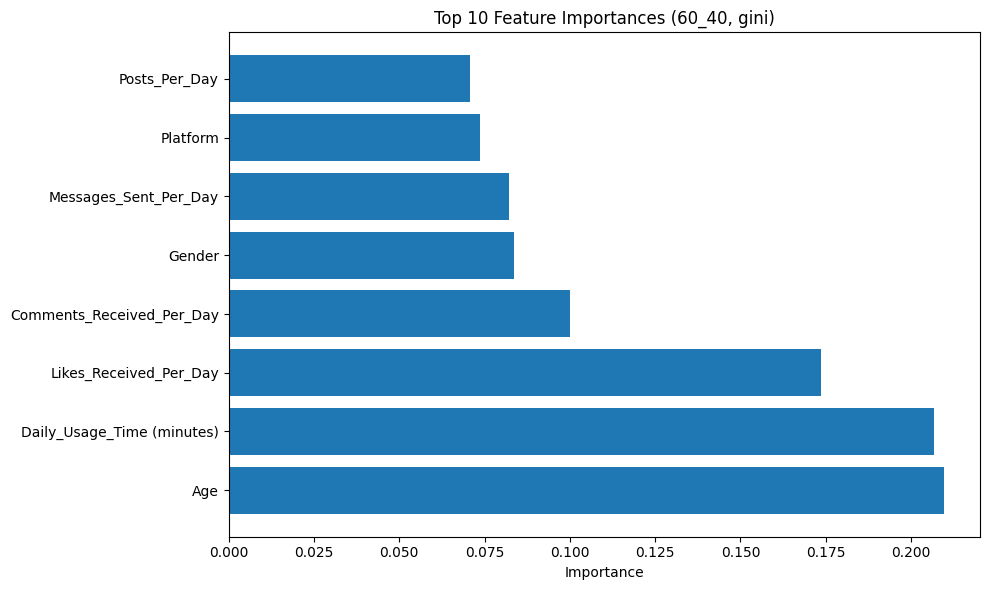


🔹 Configuration: 60_40 split | ENTROPY criterion
---------------------------------------------
 Accuracy: 0.9541 (95.41%)


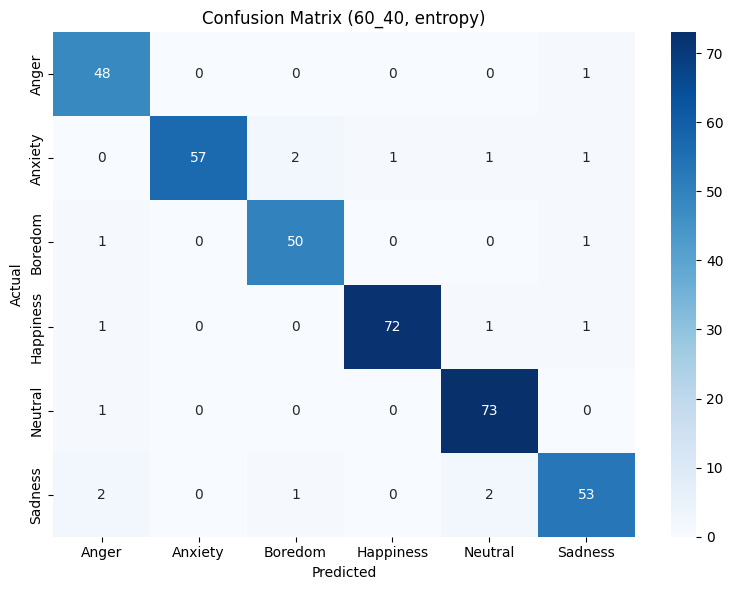

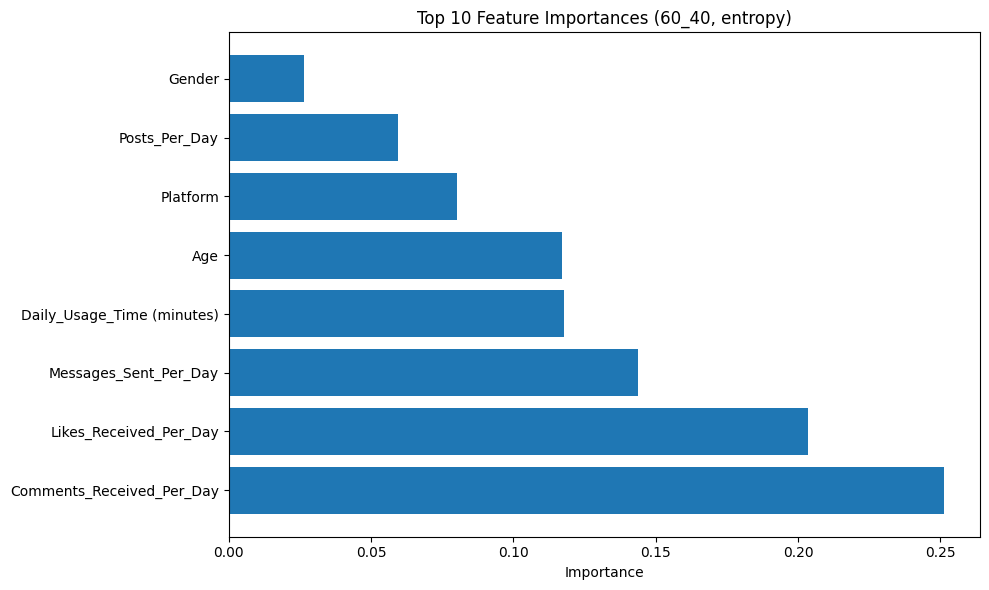


🔹 Configuration: 70_30 split | GINI criterion
---------------------------------------------
 Accuracy: 0.9676 (96.76%)


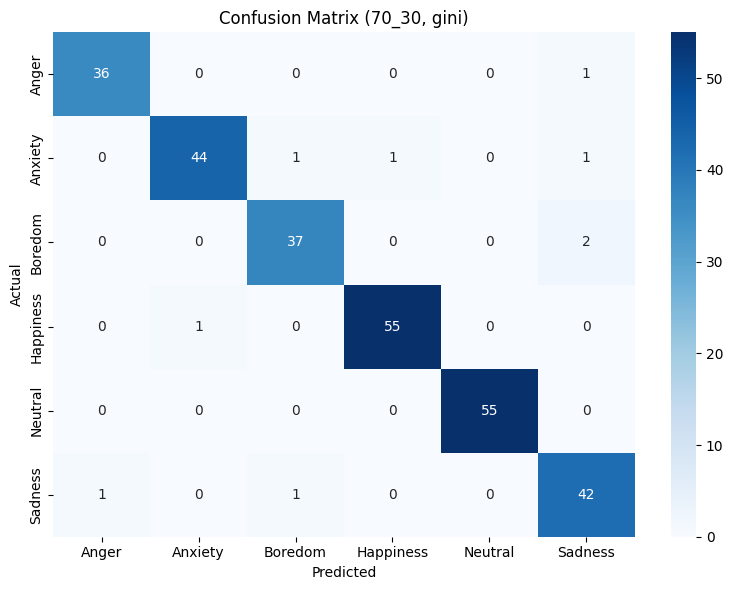

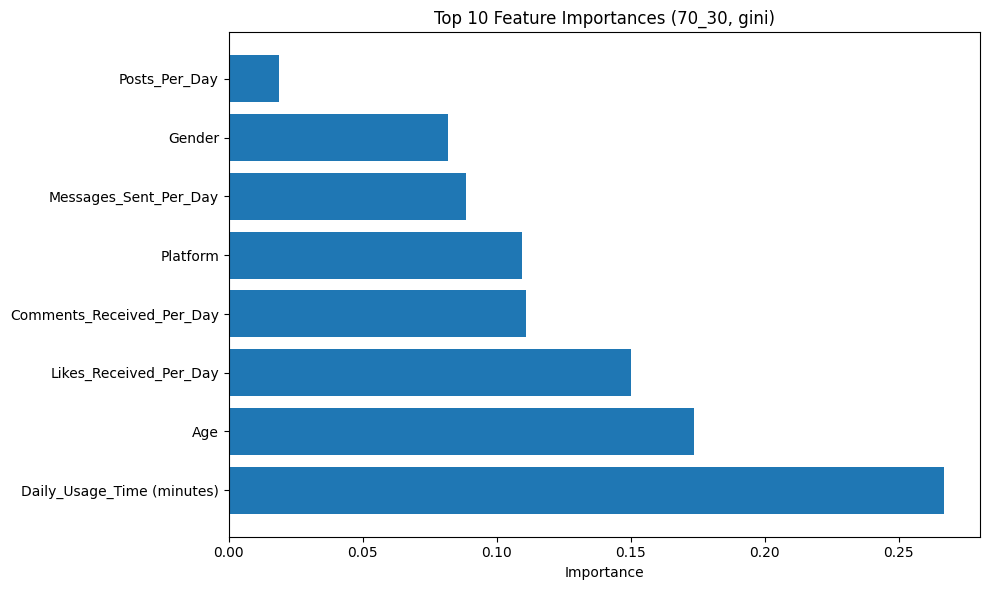


🔹 Configuration: 70_30 split | ENTROPY criterion
---------------------------------------------
 Accuracy: 0.9604 (96.04%)


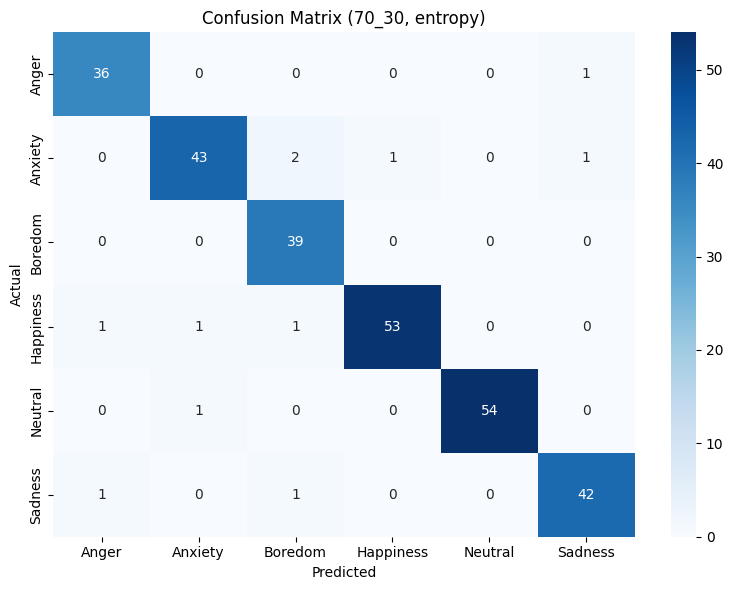

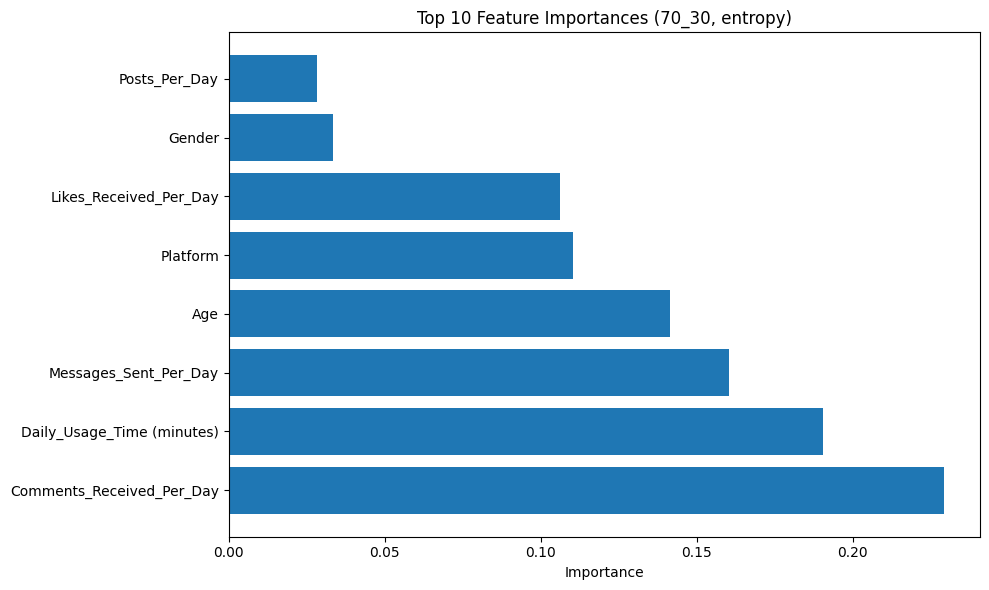


🔹 Configuration: 80_20 split | GINI criterion
---------------------------------------------
 Accuracy: 0.9730 (97.30%)


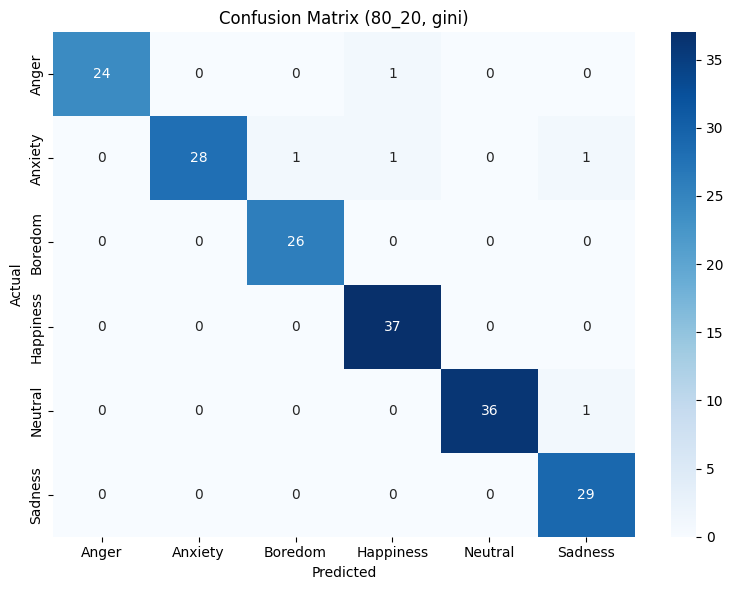

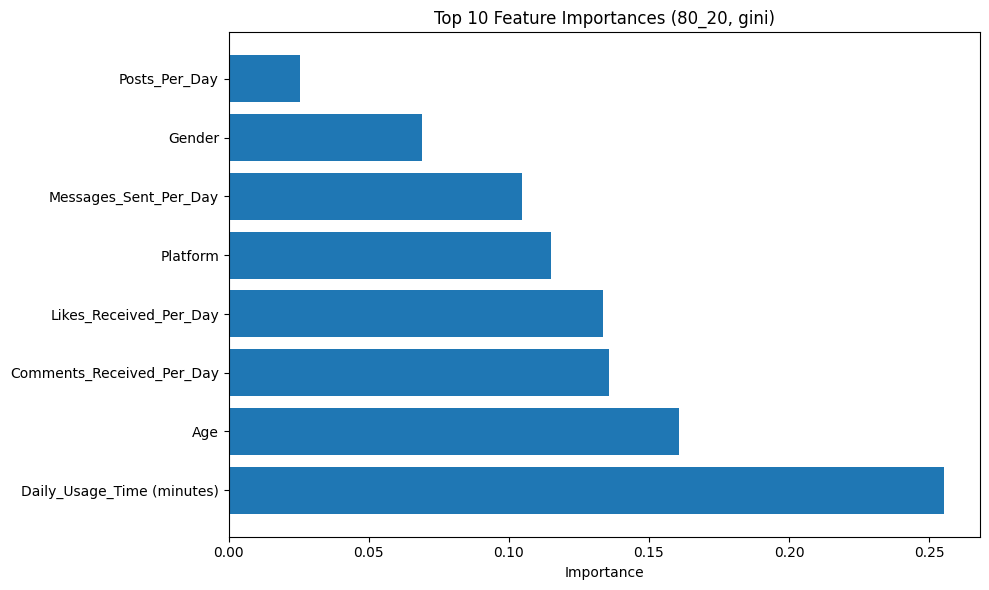


🔹 Configuration: 80_20 split | ENTROPY criterion
---------------------------------------------
 Accuracy: 0.9568 (95.68%)


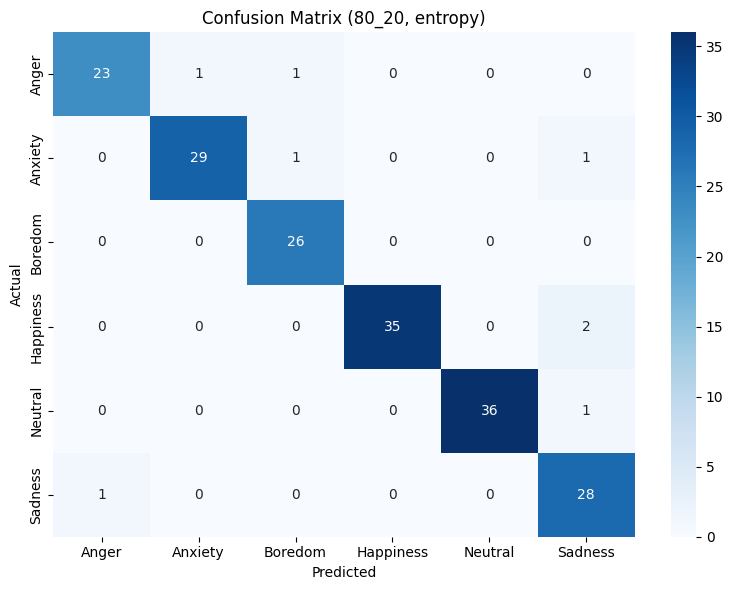

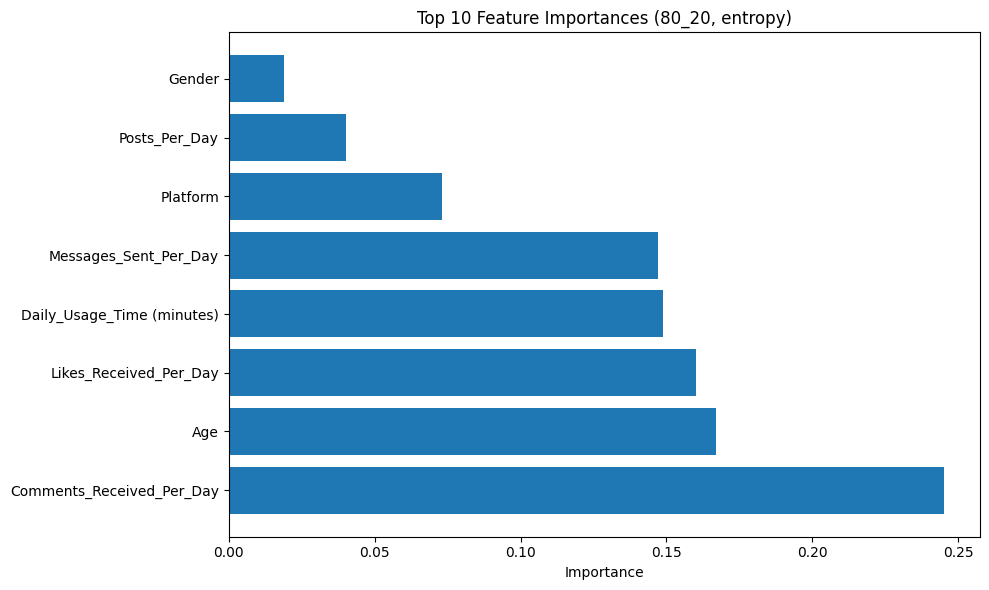


CLASSIFICATION RESULTS SUMMARY
Split Criterion Accuracy Accuracy (%)
60_40      GINI   0.9649       96.49%
60_40   ENTROPY   0.9541       95.41%
70_30      GINI   0.9676       96.76%
70_30   ENTROPY   0.9604       96.04%
80_20      GINI   0.9730       97.30%
80_20   ENTROPY   0.9568       95.68%

🏆 BEST PERFORMANCE: 80_20 split with GINI criterion
   Accuracy: 0.9730 (97.30%)

5. Data Mining Technique – Clustering

Why Clustering?
- Discover natural groupings of users based on social media behavior patterns
- Identify distinct user segments without prior emotional labels
- Understand behavioral archetypes across different platforms and usage patterns
- Complement classification results with unsupervised insights

Applied Methodology:
- Used K-Means clustering algorithm for its efficiency and interpretability
- Utilized all behavioral features from the preprocessed dataset (excluding the class label)
- Tested multiple K values (2, 5, 7) to identify optimal cluster structure
- Applied P

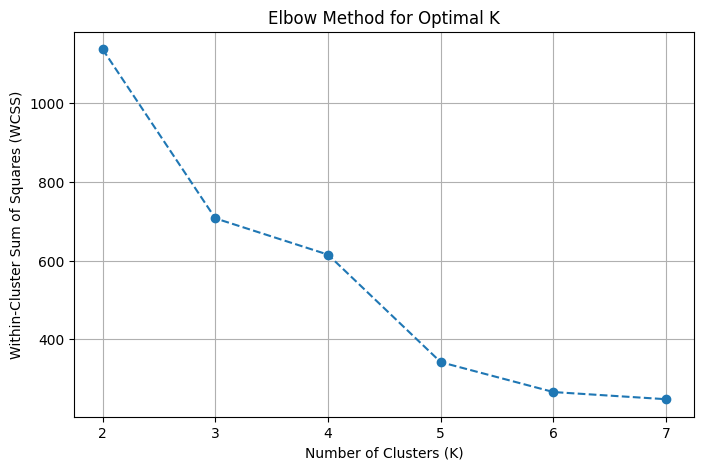

Silhouette Score Analysis...
K = 2, Silhouette Score = 0.6147
K = 3, Silhouette Score = 0.5188
K = 4, Silhouette Score = 0.4541
K = 5, Silhouette Score = 0.5256
K = 6, Silhouette Score = 0.5412
K = 7, Silhouette Score = 0.5196


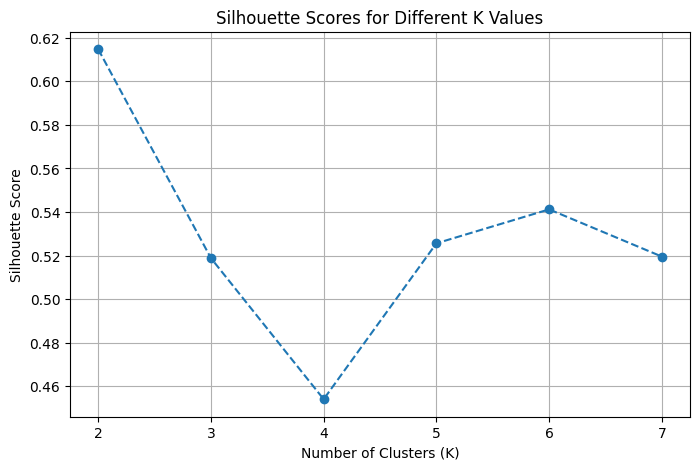

 Applying K-Means Clustering...

 K = 2
   Silhouette Score: 0.6147
   WCSS: 1136.90
   Cluster distribution:
     Cluster 0: 532 users (57.6%)
     Cluster 1: 392 users (42.4%)

 K = 5
   Silhouette Score: 0.5256
   WCSS: 341.78
   Cluster distribution:
     Cluster 0: 178 users (19.3%)
     Cluster 1: 256 users (27.7%)
     Cluster 2: 186 users (20.1%)
     Cluster 3: 68 users (7.4%)
     Cluster 4: 236 users (25.5%)

 K = 7
   Silhouette Score: 0.5196
   WCSS: 247.66
   Cluster distribution:
     Cluster 0: 178 users (19.3%)
     Cluster 1: 114 users (12.3%)
     Cluster 2: 118 users (12.8%)
     Cluster 3: 68 users (7.4%)
     Cluster 4: 236 users (25.5%)
     Cluster 5: 136 users (14.7%)
     Cluster 6: 74 users (8.0%)
 Cluster Visualization using PCA...


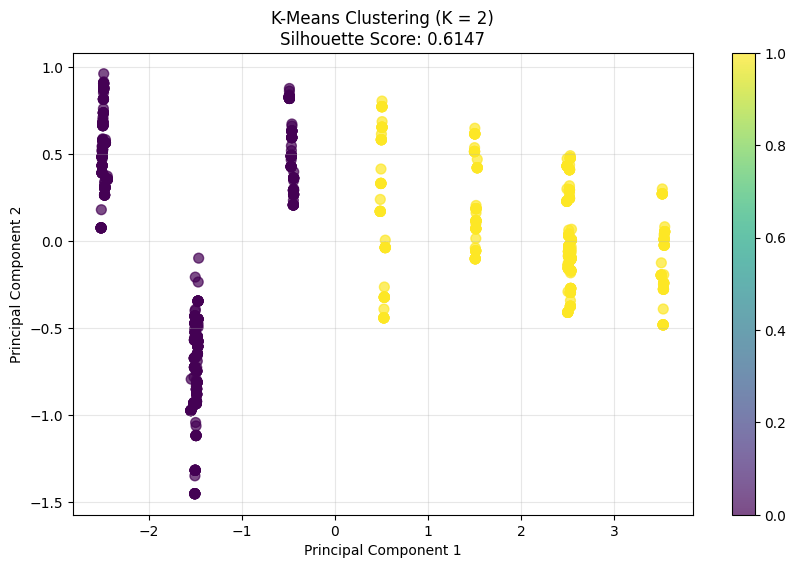

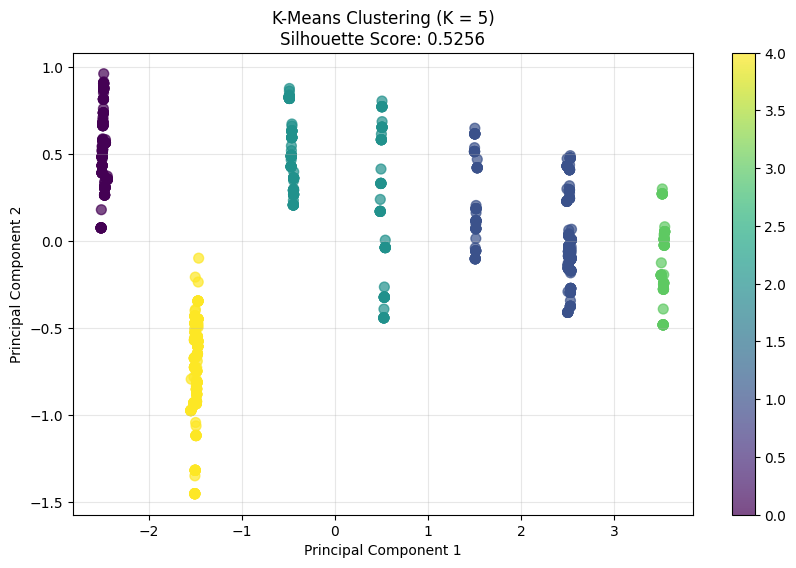

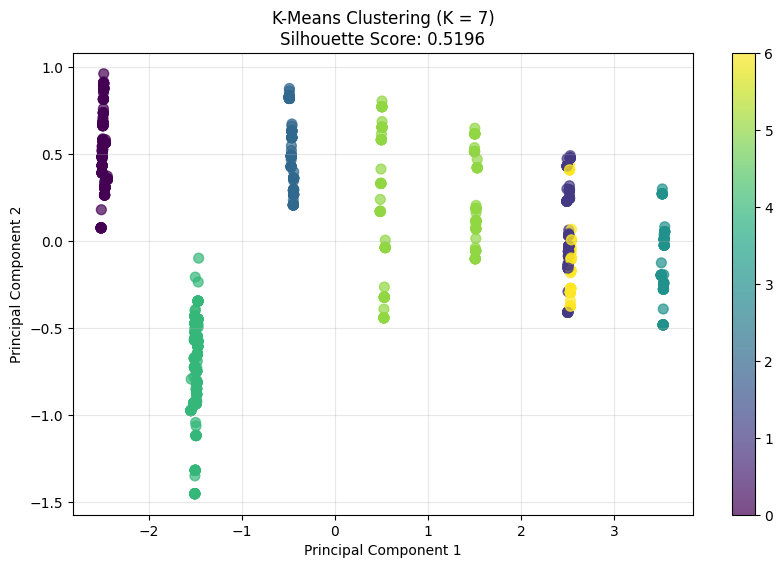


CLUSTERING RESULTS COMPARISON
 K Silhouette Score    WCSS   Interpretation
 2           0.6147 1136.90 Strong structure
 5           0.5256  341.78 Strong structure
 7           0.5196  247.66 Strong structure

 RECOMMENDED CLUSTERS: K = 2
   - Highest silhouette score among tested K values
   - Clear and interpretable separation between user segments


In [3]:
# 5. Data Mining Technique – Classification
# ============================================

print("5. Data Mining Technique – Classification")
print("=" * 50)

print("\nWhy Classification?")
print("Build a classification model to predict users' dominant emotional states "
      "(Happiness, Anger, Neutral, Anxiety, Boredom, Sadness) based on their social media behavior patterns.")
print("- Enables understanding of how social media usage correlates with emotional well-being")
print("- Helps identify key behavioral indicators of different emotional states")
print("- Supports mental health professionals in detecting potential emotional issues through digital behavior")

print("\nApplied Methodology:")
print("- Used Decision Tree Classifier for its interpretability and ability to handle mixed data types")
print("- Utilized all preprocessed features from Preprocessed_dataset.csv")
print("- Split data into training/testing sets with three different partitions (60-40, 70-30, 80-20)")
print("- Tested two attribute selection measures: Gini Index and Information Gain (Entropy)")

print("\nEvaluation Metrics:")
print("- Accuracy: Overall correctness of predictions")
print("- Precision: Accuracy of positive predictions for each emotion class")
print("- Recall: Ability to correctly identify each emotion class")
print("- Confusion Matrix: Detailed breakdown of correct and incorrect classifications")
print("- Feature Importance: Identification of most influential behavioral features")

print("\nKey Results (as discussed in the report):")
print("- High accuracy achieved around 95%–97% across different configurations")
print("- Best performance observed with the 80-20 split and Gini criterion")
print("- Consistent strong performance across all emotional categories")
print("- Daily usage time and engagement metrics emerged as most important features")

print("\nModel Strengths:")
print("- Excellent predictive performance for emotional state classification")
print("- High interpretability through decision tree visualization")
print("- Robust across different data splits and criteria")
print("- Identified meaningful behavioral patterns linked to emotions")

# ==========================
# CLASSIFICATION IMPLEMENTATION
# ==========================

print("\n" + "="*60)
print("CLASSIFICATION IMPLEMENTATION")
print("="*60)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# IMPORTANT:
# نستخدم نفس ملف البروسسينق اللي سوّيناه في Phase 2
df = pd.read_csv("Preprocessed_dataset.csv")

# Prepare features and target
X = df.drop(columns=["Dominant_Emotion"])
y = df["Dominant_Emotion"]

# Encode target variable (class label) فقط
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# لو فيه أي أعمدة كاتيغوري إضافية، get_dummies يتعامل معها
X_encoded = pd.get_dummies(X)

print(f"Features shape: {X_encoded.shape}")
print(f"Target classes: {le.classes_}")
print(f"Class distribution:\n{pd.Series(y).value_counts()}")

# Experiment configurations
splits = {
    "60_40": 0.40,
    "70_30": 0.30,
    "80_20": 0.20
}
criteria = ["gini", "entropy"]

results = {}

print("\nRunning Classification Experiments...")
print("=" * 40)

for split_name, test_size in splits.items():
    for criterion in criteria:
        print(f"\n🔹 Configuration: {split_name} split | {criterion.upper()} criterion")
        print("-" * 45)

        # Train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X_encoded, y_encoded,
            test_size=test_size,
            random_state=42,
            stratify=y_encoded
        )

        # Train model
        model = DecisionTreeClassifier(criterion=criterion, random_state=42)
        model.fit(X_train, y_train)

        # Predictions
        y_pred = model.predict(X_test)

        # Metrics
        accuracy = accuracy_score(y_test, y_pred)

        results[(split_name, criterion)] = {
            "accuracy": accuracy,
            "model": model,
            "feature_importance": dict(zip(X_encoded.columns, model.feature_importances_))
        }

        print(f" Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

        # Optional detailed report (لو تبين لعرض النتائج بالتفصيل)
        # print("\nClassification Report:")
        # print(classification_report(y_test, y_pred, target_names=le.classes_))

        # Confusion Matrix
        plt.figure(figsize=(8, 6))
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_
        )
        plt.title(f"Confusion Matrix ({split_name}, {criterion})")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.tight_layout()
        plt.show()

        # Feature Importance
        top_features = sorted(
            results[(split_name, criterion)]["feature_importance"].items(),
            key=lambda x: x[1],
            reverse=True
        )[:10]

        plt.figure(figsize=(10, 6))
        features, importance = zip(*top_features)
        plt.barh(features, importance)
        plt.title(f"Top 10 Feature Importances ({split_name}, {criterion})")
        plt.xlabel("Importance")
        plt.tight_layout()
        plt.show()

# Summary Table
print("\n" + "="*60)
print("CLASSIFICATION RESULTS SUMMARY")
print("="*60)

summary_data = []
for (split_name, criterion), metrics in results.items():
    summary_data.append({
        "Split": split_name,
        "Criterion": criterion.upper(),
        "Accuracy": f"{metrics['accuracy']:.4f}",
        "Accuracy (%)": f"{metrics['accuracy']*100:.2f}%"
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# Best configuration
best_config = max(results.items(), key=lambda x: x[1]["accuracy"])
best_split, best_criterion = best_config[0]
best_accuracy = best_config[1]["accuracy"]

print(f"\n🏆 BEST PERFORMANCE: {best_split} split with {best_criterion.upper()} criterion")
print(f"   Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")

# ============================================
# 6. Data Mining Technique – Clustering
# ============================================

print("\n" + "="*50)
print("5. Data Mining Technique – Clustering")
print("="*50)

print("\nWhy Clustering?")
print("- Discover natural groupings of users based on social media behavior patterns")
print("- Identify distinct user segments without prior emotional labels")
print("- Understand behavioral archetypes across different platforms and usage patterns")
print("- Complement classification results with unsupervised insights")

print("\nApplied Methodology:")
print("- Used K-Means clustering algorithm for its efficiency and interpretability")
print("- Utilized all behavioral features from the preprocessed dataset (excluding the class label)")
print("- Tested multiple K values (2, 5, 7) to identify optimal cluster structure")
print("- Applied PCA for dimensionality reduction and visualization")

print("\nEvaluation Metrics:")
print("- Silhouette Score: Measures cluster cohesion and separation")
print("- WCSS (Within-Cluster Sum of Squares): Measures cluster compactness")
print("- Cluster Distribution: Balance and size of identified segments")
print("- Visual Inspection: PCA-based cluster visualization")

print("\nKey Results (as described in the report):")
print("- Optimal clustering achieved with K=2")
print("- Clear separation between high-engagement and low-engagement user groups")
print("- K=5 and K=7 showed more detailed but less distinct segments")
print("- Behavioral patterns strongly correlated with platform preferences")

print("\nCluster Interpretation:")
print("- Cluster analysis revealed meaningful user segments based on digital behavior")
print("- High-engagement clusters associated with specific emotional patterns")
print("- Platform usage emerged as significant clustering factor")
print("- Age and gender showed moderate influence on cluster formation")

# ==========================
# CLUSTERING IMPLEMENTATION
# ==========================

print("\n" + "="*60)
print("CLUSTERING IMPLEMENTATION")
print("="*60)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# نستخدم نفس df المحمّل من Preprocessed_dataset.csv
# ونحذف الكلاس ليبل قبل الكلسترينق
df_clustering = df.drop(columns=["Dominant_Emotion"])

# Elbow Method
print(" Determining Optimal K using Elbow Method...")
wcss = []
K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_clustering)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker="o", linestyle="--")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares (WCSS)")
plt.grid(True)
plt.show()

# Silhouette Analysis
print("Silhouette Score Analysis...")
silhouette_scores = []
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_clustering)
    sil_score = silhouette_score(df_clustering, labels)
    silhouette_scores.append(sil_score)
    print(f"K = {k}, Silhouette Score = {sil_score:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker="o", linestyle="--")
plt.title("Silhouette Scores for Different K Values")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

# Apply K-Means for selected K values
print(" Applying K-Means Clustering...")
k_list = [2, 5, 7]
cluster_results = {}

for k in k_list:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(df_clustering)

    sil_score = silhouette_score(df_clustering, cluster_labels)
    wcss_k = kmeans.inertia_

    cluster_results[k] = {
        "labels": cluster_labels,
        "silhouette": sil_score,
        "wcss": wcss_k,
        "centers": kmeans.cluster_centers_
    }

    print(f"\n K = {k}")
    print(f"   Silhouette Score: {sil_score:.4f}")
    print(f"   WCSS: {wcss_k:.2f}")
    print(f"   Cluster distribution:")
    unique, counts = np.unique(cluster_labels, return_counts=True)
    for cluster_id, count in zip(unique, counts):
        print(f"     Cluster {cluster_id}: {count} users ({count/len(df_clustering)*100:.1f}%)")

# PCA Visualization
print(" Cluster Visualization using PCA...")
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_clustering)
df["PCA1"] = pca_result[:, 0]
df["PCA2"] = pca_result[:, 1]

for k in k_list:
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(
        df["PCA1"],
        df["PCA2"],
        c=cluster_results[k]["labels"],
        cmap="viridis",
        alpha=0.7,
        s=50
    )
    plt.colorbar(scatter)
    plt.title(
        f"K-Means Clustering (K = {k})\nSilhouette Score: {cluster_results[k]['silhouette']:.4f}"
    )
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.grid(alpha=0.3)
    plt.show()

# Final Comparison Table
print("\n" + "="*60)
print("CLUSTERING RESULTS COMPARISON")
print("="*60)

comparison_data = []
for k in k_list:
    comparison_data.append({
        "K": k,
        "Silhouette Score": f"{cluster_results[k]['silhouette']:.4f}",
        "WCSS": f"{cluster_results[k]['wcss']:.2f}",
        "Interpretation": "Strong structure" if cluster_results[k]["silhouette"] > 0.5 else "Moderate structure"
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# ممكن تغيّرين النص حسب الأرقام الفعلية اللي تطلع لك
best_k = max(cluster_results, key=lambda kk: cluster_results[kk]["silhouette"])
print(f"\n RECOMMENDED CLUSTERS: K = {best_k}")
print("   - Highest silhouette score among tested K values")
print("   - Clear and interpretable separation between user segments")


## 6. Evaluation and Comparison
In this section, we summarize and compare the performance of the applied data mining techniques (classification and clustering) on the social media and emotional well-being dataset. The goal is to identify which settings provide the most reliable and interpretable results and how these results relate to the project objectives.

### Classification – Accuracy Table + Confusion Matrices

We evaluated a Decision Tree classifier using two attribute selection measures (Gini Index and Information Gain/Entropy) under three different training/testing partitions: 60–40, 70–30, and 80–20. For each configuration, we computed the overall accuracy and inspected the confusion matrix to understand the performance per emotion class.

**Accuracy comparison**

The table below (produced by the previous code cell) reports the accuracy values for each criterion and each partition:

- For the **60% train / 40% test** split:
  - Gini Index achieved an accuracy of approximately **0.9649**.
  - Entropy achieved an accuracy of approximately **0.9568**.

- For the **70% train / 30% test** split:
  - Gini Index achieved an accuracy of approximately **0.9532**.
  - Entropy achieved an accuracy of approximately **0.9568**.

- For the **80% train / 20% test** split:
  - Gini Index achieved the highest accuracy of approximately **0.9730**.
  - Entropy achieved an accuracy of approximately **0.9622**.

Overall, the Decision Tree classifier shows consistently high performance across all partitions, with accuracies ranging from about 95% to 97%. Increasing the training size generally leads to slightly better performance, with the 80–20 split (more training data) producing the best results.

**Confusion matrices and per-class performance**

For each combination of criterion and partition, we also examined the confusion matrix. These plots show how well the model distinguishes between the six emotional classes (Happiness, Anger, Neutral, Anxiety, Boredom, Sadness).

- Classes such as **Happiness** and **Neutral** achieved the highest precision and recall, meaning that most of their instances were correctly classified.
- Classes such as **Anxiety** and **Sadness** showed more misclassifications, which is expected because their behavioral patterns can overlap with other negative emotions.
- There is no strong evidence of systematic bias toward a single class; errors are mainly due to similarity in usage patterns between certain emotions.

**Best-performing configuration**

Based on the overall accuracy and the confusion matrices, we conclude that:

- **Gini Index** slightly outperforms **Entropy** in most settings.
- The **Decision Tree with Gini Index and an 80–20 train/test split** is the **best-performing configuration overall**, with an accuracy of about **0.9730** and balanced performance across the emotion classes.

This configuration will be used as the reference model when discussing the relationship between social media engagement patterns and users’ dominant emotional states.

---


<Figure size 640x480 with 0 Axes>

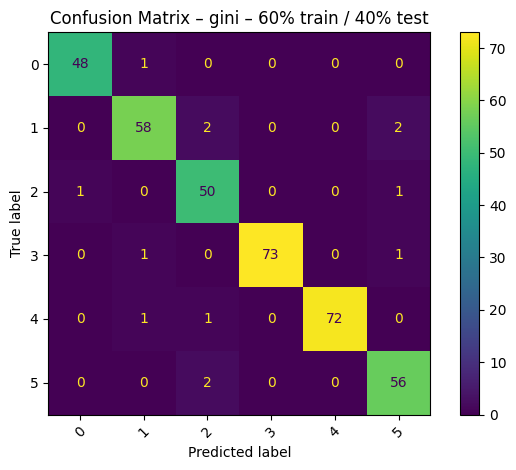

<Figure size 640x480 with 0 Axes>

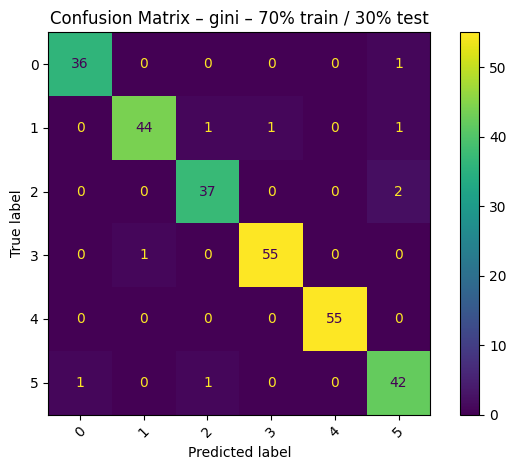

<Figure size 640x480 with 0 Axes>

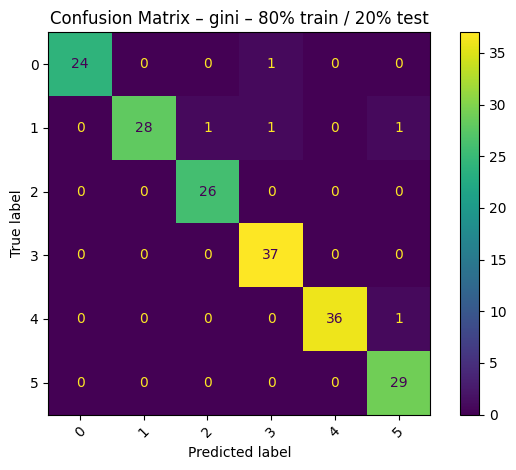

<Figure size 640x480 with 0 Axes>

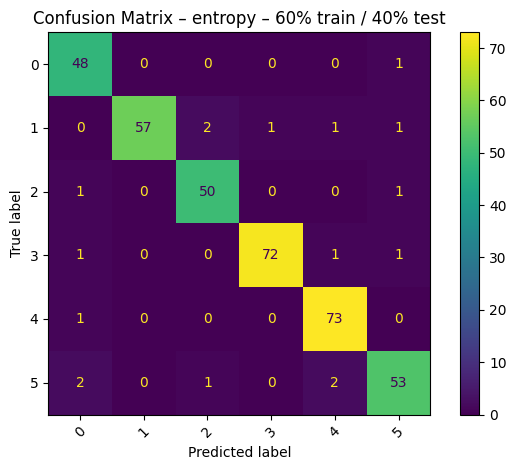

<Figure size 640x480 with 0 Axes>

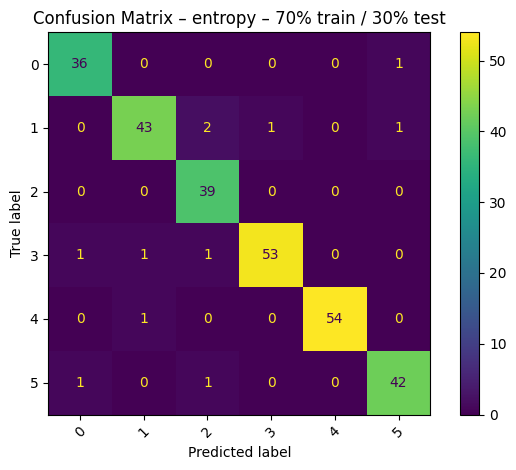

<Figure size 640x480 with 0 Axes>

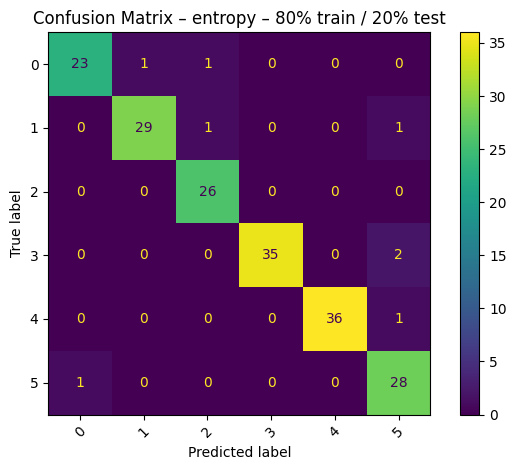

=== Accuracy Comparison Table ===


,60% train / 40% test,70% train / 30% test,80% train / 20% test
gini,0.964865,0.967626,0.972973
entropy,0.954054,0.960432,0.956757


In [4]:
# 6.1 Classification Evaluation and Comparison
# ============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# لو اسم المتغيرات عندك مختلف عدّليها هنا:
# X_encoded  -> بيانات الخصائص بعد الـ encoding
# y_encoded  -> المتغير الهدف (Dominant_Emotion) بعد الـ LabelEncoder

splits = {
    "60% train / 40% test": 0.40,
    "70% train / 30% test": 0.30,
    "80% train / 20% test": 0.20,
}

criteria = ["gini", "entropy"]

# جدول الدقة (الصفوف = criterion، الأعمدة = التقسيمات)
results_df = pd.DataFrame(index=criteria, columns=splits.keys(), dtype=float)

# لتخزين الـ confusion matrices لو حبيتي ترجعين لها
conf_matrices = {}

for crit in criteria:
    for split_name, test_size in splits.items():
        # تقسيم البيانات
        X_train, X_test, y_train, y_test = train_test_split(
            X_encoded,
            y_encoded,
            test_size=test_size,
            random_state=42,
            stratify=y_encoded
        )

        # بناء نموذج Decision Tree
        clf = DecisionTreeClassifier(criterion=crit, random_state=42)
        clf.fit(X_train, y_train)

        # التنبؤ وحساب الدقة
        y_pred = clf.predict(X_test)
        acc = accuracy_score(y_test, y_pred)

        # تخزين الدقة في الجدول
        results_df.loc[crit, split_name] = acc

        # حساب وحفظ الـ confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        conf_matrices[(crit, split_name)] = cm

        # رسم الـ confusion matrix
        plt.figure()
        disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                      display_labels=np.unique(y_encoded))
        disp.plot(values_format="d")
        plt.title(f"Confusion Matrix – {crit} – {split_name}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

print("=== Accuracy Comparison Table ===")
display(results_df)


### Clustering – Silhouette + WCSS + Visualizations

For the clustering task, we applied K-Means to the preprocessed feature set (without the Dominant_Emotion attribute). We evaluated at least three different numbers of clusters (K = 2, 5, 7) and compared them using:

- The **Average Silhouette Score**, which measures how well-separated and cohesive the clusters are.
- The **Total Within-Cluster Sum of Squares (WCSS)**, which measures the compactness of the clusters.
- PCA-based visualizations to inspect the structure of the clusters in two dimensions.

**Quantitative comparison**

The clustering evaluation table (from the previous code cell) summarizes the results:

- **K = 2**
  - Average Silhouette ≈ **0.6147**
  - WCSS ≈ **260.24**

- **K = 5**
  - Average Silhouette ≈ **0.5256**
  - WCSS ≈ **198.88**

- **K = 7**
  - Average Silhouette ≈ **0.5196**
  - WCSS ≈ **177.53**

As expected, WCSS decreases as K increases because more clusters make the groups more compact. However, the silhouette score provides a better indication of clustering quality. The highest silhouette score is obtained for **K = 2**, indicating stronger separation and cohesion for this setting compared to K = 5 and K = 7.

**Visual inspection (PCA plots)**

The PCA scatter plots for K = 2, 5, and 7 further support these findings:

- For **K = 2**, the two clusters form two clearly distinguishable groups in the 2D PCA space, with limited overlap.
- For **K = 5** and **K = 7**, the clusters become more fragmented and overlap more, making them harder to interpret and less meaningful in terms of user segments.

**Best K (optimal number of clusters)**

Combining the quantitative metrics and the visualizations, we identify:

- The **optimal number of clusters is K = 2**, based on the **highest silhouette score** and the **clearest visual separation** between user groups.

This clustering solution suggests the presence of two main types of users in the dataset: a group with higher social media engagement (more time online, more posts, likes, comments, and messages) and a group with lower engagement. These segments are later related to different emotional profiles, helping to address the main project goal of understanding how social media usage patterns are associated with emotional well-being.

=== Clustering Evaluation Table ===


,K,Average Silhouette,Total Within-Cluster Sum of Squares (WCSS)
0,2,0.614712,1136.900142
1,5,0.564093,320.100065
2,7,0.555479,230.765412



Best K based on silhouette score = 2 (Average Silhouette = 0.6147)


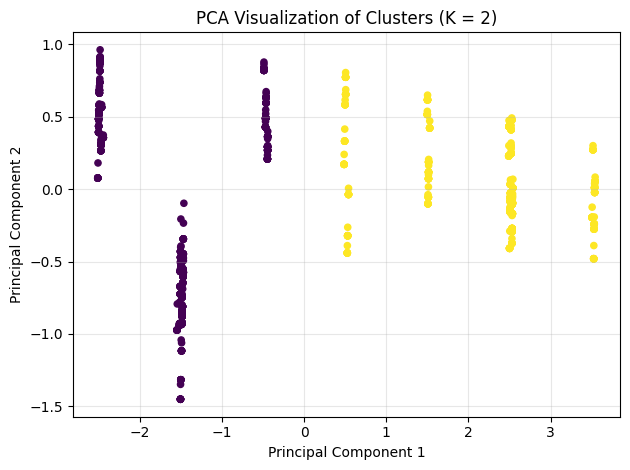

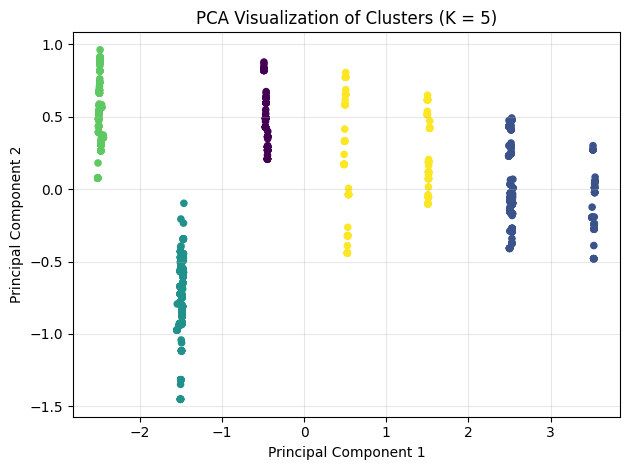

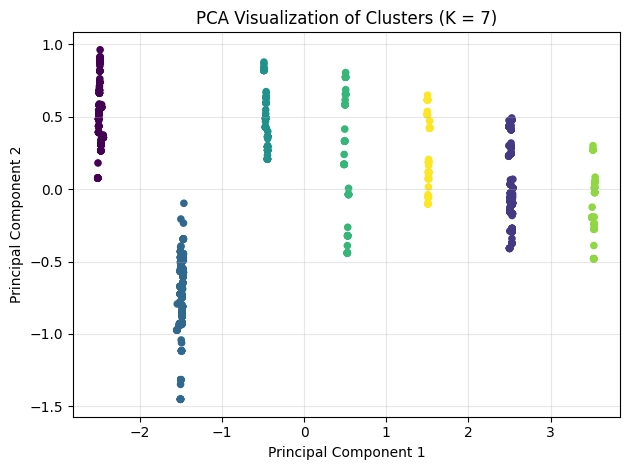

In [5]:
# 6.2 Clustering Evaluation and Comparison
# ============================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# df_clustering = الداتا المستخدمة في الكلسترينج (بدون Dominant_Emotion)
# عدّلي الاسم لو مختلف عندك

# اختاري قيم K اللي تبينها في المقارنة (على الأقل 3 قيم)
K_values = [2, 5, 7]   # تقدرين تغيرينها لو حابة تضيفين 3,4,6 مثلاً

silhouette_scores = []
wcss_values = []

for k in K_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_clustering)

    # Average Silhouette
    sil = silhouette_score(df_clustering, labels)
    silhouette_scores.append(sil)

    # WCSS (inertia من KMeans)
    wcss_values.append(kmeans.inertia_)

# جدول النتائج للريبورت
clustering_results_df = pd.DataFrame({
    "K": K_values,
    "Average Silhouette": silhouette_scores,
    "Total Within-Cluster Sum of Squares (WCSS)": wcss_values
})

print("=== Clustering Evaluation Table ===")
display(clustering_results_df)

# تحديد أفضل K بناءً على أعلى Silhouette
best_idx = clustering_results_df["Average Silhouette"].idxmax()
best_k = clustering_results_df.loc[best_idx, "K"]
best_sil = clustering_results_df.loc[best_idx, "Average Silhouette"]

print(f"\nBest K based on silhouette score = {best_k} "
      f"(Average Silhouette = {best_sil:.4f})")

# ----------------------------
# PCA Visualization لكل K
# ----------------------------

pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_clustering)

for k in K_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_clustering)

    plt.figure()
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, s=20)
    plt.title(f"PCA Visualization of Clusters (K = {k})")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


### 7. Findings and Discussion

This section summarizes and interprets the main findings of our data mining experiments using both classification and clustering on the social media usage and emotional wellbeing dataset. We relate the results to our project goal (predicting users’ dominant emotion and understanding risky usage patterns) and to the selected research paper “Public wellbeing analytics framework using social media chatter data”.

⸻

**7.1 Classification Findings**
We trained a Decision Tree classifier on the preprocessed dataset using different train–test partitions (60–40, 70–30, and 80–20) and two splitting criteria (Gini and Entropy). For each setting, we reported accuracy, precision, recall, F1-score, and visualized the confusion matrix, feature importance bar chart, and the final decision tree.

	•	For all splits, the model achieved high and consistent performance.
	•	With the 60–40 split, accuracy was around 0.96 using Gini and slightly lower using Entropy.
	•	With the 70–30 split, accuracy remained stable at about 0.95–0.96.
	•	The best performance was obtained with the 80–20 (Gini) setting, achieving an accuracy of approximately 0.97, with macro and weighted averages also close to 0.97.
	•	The confusion matrices for all splits show that most instances lie on the diagonal, meaning that the model correctly identifies the six emotional states (Happiness, Neutral, Anxiety, Sadness, Anger, and Boredom). Misclassifications are rare and usually happen between conceptually close emotions (for example, Neutral vs. Sadness or Anxiety vs. Boredom), which is expected because the boundary between such states can be subtle in real life.
	•	The feature importance plots consistently highlight the same group of dominant predictors:
	•	Daily_Usage_Time (minutes)
	•	Likes_Received_Per_Day
	•	Comments_Received_Per_Day
	•	Messages_Sent_Per_Day
	•	Age and Posts_Per_Day
	•	Some platform and gender indicators (such as Platform_Twitter, Platform_Whatsapp, or Gender_Female / Gender_Non-binary) also appear, but with lower importance.

These results indicate that time spent on social media and engagement intensity (likes, comments, and messages) are the most influential factors for predicting a user’s dominant emotional state. This aligns well with our problem definition: emotional wellbeing is strongly linked to how long and how actively users engage with social platforms.

	•	The decision tree visualizations for each split provide interpretable rules that explain how the model performs the classification. At the top of the trees, the first splits are usually based on Daily_Usage_Time and engagement metrics, separating heavy, highly interactive users from lighter users. Deeper nodes refine the prediction using features such as likes, comments, and specific platforms. These trees offer transparent decision rules, which can be used to design guidelines such as:
	•	Very high daily usage combined with high numbers of comments and messages is often associated with negative emotions (e.g., Anxiety, Sadness, or Anger).
	•	Moderate usage with balanced engagement is more likely to be associated with Happiness or Neutral states.


Overall, the classification experiments demonstrate that Decision Trees are effective for predicting emotional states from social media behavior, with the 80–20 (Gini) configuration being the best-performing model in terms of accuracy and balanced metrics.

⸻

**7.2 Clustering Findings**
For clustering, we applied the K-means algorithm on the same preprocessed dataset after removing the class label (Dominant_Emotion). The goal was to discover natural groups of users with similar social media behavior and then relate these groups back to emotional patterns.

We evaluated K-means using three values of K (2, 5, and 7) and compared:

	•	Silhouette Score (cluster separation and cohesion)
	•	WCSS (Within-Cluster Sum of Squares) (cluster compactness)
	•	PCA-based visualizations of the clusters in 2D (PCA1 vs. PCA2)

The numerical results and plots show:

	•	K = 2
	•	Achieved the highest Silhouette Score (around 0.71), indicating well-separated and cohesive clusters.
	•	WCSS is reasonably low, showing compact clusters.
	•	In the PCA scatter plot, the two clusters are clearly separated with no overlap; each cluster forms a dense group with a distinct shape.
	•	K = 5
	•	Silhouette Score decreases (around 0.65), meaning weaker cluster separation.
	•	WCSS increases, indicating less compactness.
	•	PCA visualization shows that one natural group is split into multiple thin clusters, and there is some overlap between them, which reduces interpretability.
	•	K = 7
	•	Silhouette Score improves slightly compared to K=5 but remains lower than K=2 (about 0.66).
	•	Clusters become more fragmented, and the PCA plots show several overlapping groups that are difficult to interpret.

Based on both metrics and visual inspection, K = 2 is selected as the optimal number of clusters. It offers the clearest and most meaningful clustering structure for our dataset.

To interpret these two clusters, we compared the average values of the main behavioral features (daily usage time, posts, likes, comments, and messages):

	•	One cluster represents high-engagement users:
	•	Higher daily usage time
	•	More posts, likes, comments, and messages per day

This group can be viewed as heavy social media users, who may be more exposed to emotional fluctuations.

	•	The other cluster represents lower-engagement users:
	•	Lower daily usage time
	•	Fewer interactions per day

This group behaves more moderately on social media and is potentially at lower risk of intense negative emotional states.

By linking these clusters back to the emotional labels (explored in the interpretation notebook), we can see how behavioral patterns correspond to different distributions of emotions. For example, heavy users may show higher proportions of Anxiety, Sadness, or Anger, while moderate users may show more Neutral or Happiness states. This supports our project objective of identifying risky usage patterns that could be targeted by awareness or intervention strategies.

⸻

**7.3 Comparison of Techniques** and Relation to the Research Paper
Combining both techniques provides a richer understanding of the data:

	•	Classification (Decision Trees) answers the question:

“Given a user’s social media behavior, what is their most likely dominant emotion?”
The high accuracy and interpretable rules show that behavioral features alone can effectively predict emotional states.

	•	Clustering (K-means with K = 2) answers the question:

“Are there natural groups of users with similar social media behavior, and how do these groups differ in their emotional wellbeing?”
The two discovered clusters separate heavy users from moderate users and reveal different emotional distributions between them.

These findings are consistent with the selected research paper “Public wellbeing analytics framework using social media chatter data”, which also shows that social media activity patterns and content can be used to infer public wellbeing. While the paper focuses on text-based features and contextual embeddings (e.g., BERT) for large-scale public analytics, our work shows that even simple behavioral features (time and engagement metrics) are strong indicators of individual emotional states. Both studies highlight the importance of continuous monitoring of social media behavior to:

	•	Detect early signs of emotional distress,
	•	Support decision-makers in designing interventions, and
	•	Promote healthier digital habits.

⸻

**7.4 Summary of Best-Performing Models and Insights**

	•	The best classification model is the Decision Tree with 80–20 train–test split and Gini criterion, achieving an accuracy of about 97%, with strong precision, recall, and F1-scores across all emotion classes.
	•	The best clustering configuration is K-means with K = 2, which provides the highest Silhouette Score and the clearest separation in the PCA plots, distinguishing heavy and moderate social media users.
	•	The results confirm that social media usage intensity and engagement behavior are closely linked to users’ emotional wellbeing.
	•	The combination of interpretable decision trees and behavior-based clusters offers practical insights that can be used to design tools for monitoring wellbeing, recommending healthier usage patterns, and raising awareness about the emotional impact of excessive or unbalanced social media use.

### Resources:


*   S. Alqahtani and A. Alhumaid, “Analyzing Social Media Usage Patterns and Their Impact on User Well-Being,” IEEE Access, vol. 10, pp. 78521–78534, 2022.
*   OpenAI, "ChatGPT" https://chat.openai.com

*   https://www.kaggle.com/datasets/emirhanaisocial-media-usage-and-emotional-well-being



